In [1]:
import os
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA

import prince
from collections import Counter
import torch
from madrigal.utils import BASE_DIR

import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
%matplotlib inline

RAW_DATA_DIR = BASE_DIR + "raw_data/pdx/"

No CUDA runtime is found, using CUDA_HOME='$CUDA_HOME/'


['str', 'kg', 'cv']


In [2]:
# load metadata
drug_metadata = pd.read_pickle(BASE_DIR + "processed_data/drug_features/drug_metadata_ddi.pkl")
drug_names = drug_metadata[['node_name', 'cmap_name']].apply(
    lambda row: (
        set([row[0].lower()] + list(name.lower() for name in row[1])) if row[1] == row[1] and row[1] is not None else set([row[0].lower()])
    ) if row[0] == row[0] and row[0] is not None else set(name.lower() for name in row[1]),
    axis=1
)

# Explore data

- Match drug combos and extract outcomes

- Correlate predictions w outcomes

- Stratify/filter models (based on indication, #tested, etc.)

- Process genomics info



In [ ]:
pdx_data_path = RAW_DATA_DIR + "pdx_data.pkl"
if not os.path.exists(pdx_data_path):
    # Parse the PDXE supplementary workbook once (slow).
    pdx_data = pd.read_excel(RAW_DATA_DIR + "41591_2015_BFnm3954_MOESM10_ESM.xlsx",
                             sheet_name=["RNAseq_fpkm", "copy number", "pdxe_mut_and_cn2", "PCT raw data", "PCT curve metrics"])
    torch.save(pdx_data, pdx_data_path)


dict_keys(['RNAseq_fpkm', 'copy number', 'pdxe_mut_and_cn2', 'PCT raw data', 'PCT curve metrics'])

In [ ]:
pdx_data = torch.load(RAW_DATA_DIR+"pdx_data.pkl")
pdx_rnaseq = pdx_data["RNAseq_fpkm"]
pdx_rnaseq = pdx_rnaseq.set_index("Sample").rename_axis(index=None)
pdx_mut = pdx_data["pdxe_mut_and_cn2"]
pdx_raw_data = pdx_data["PCT raw data"]
pdx_readouts = pdx_data["PCT curve metrics"]

del pdx_data

np.unique(pdx_rnaseq.columns).shape[0]

399

## Process response data

In [ ]:
mono_therapy_to_drug = {
    "BGJ398":"infigratinib",
    "BKM120":"buparlisib",
    "BYL719":"alpelisib",
    "HDM201":"siremadlin",
    # "HSP990"  # protein
    "INC280":"capmatinib",
    "LEE011":"ribociclib",
    # "LLM871"  # unknown structure
    "5FU":"fluorouracil",
    # "CGM097"  # unknown structure
    # "CKX620"  # unkonwn structure
    # "LJC049"  # unkonwn structure
    # "LKA136"  # unknown structure
    "INC424": "ruxolitinib",
    # "LFA102"  # antibody
    # "LGH447"  # unknown structure
    # "WNT974"  # unknown structure
    "LDE225":"sonidegib",
    "LDK378":"ceritinib",
    # "LGW813"  # unknown structure
    # "TAS266"  # unknown structure
    "abraxane":"paclitaxel",
}

In [8]:
all_pdx_drugs = list(set([drug.strip("\"").split("-")[0] for drug in pdx_readouts["Treatment"].unique() if "+" not in drug]))

temp_drug_names = drug_names.apply(lambda st: {drug.replace("-", "") for drug in st})
matched_indices = []
for drug_name in all_pdx_drugs:
    matched_indices.append(temp_drug_names.index.values[temp_drug_names.apply(
        lambda lst: (drug_name.lower() in lst) or \
        (drug_name in mono_therapy_to_drug.keys() and mono_therapy_to_drug[drug_name].lower() in lst) or \
        ("nvp"+drug_name.lower() in lst)
    )])
print([t for t, i in zip(all_pdx_drugs, matched_indices) if len(i) == 0])

pdx_drug_name_to_ind = {drug:ind for drug, ind in zip(all_pdx_drugs, matched_indices) if len(ind) > 0}
print(pdx_drug_name_to_ind)
pdx_drug_name_to_ind = {k:v[0] for k, v in pdx_drug_name_to_ind.items()}

['HSP990', 'LKA136', 'LJM716', 'untreated', 'LJC049', 'TAS266', 'trastuzumab', 'figitumumab', 'CKX620', 'LFA102', 'CLR457', 'LLM871', 'cetuximab', 'LGW813']
{'paclitaxel': array([815]), 'LDK378': array([1130]), 'trametinib': array([1110]), 'erlotinib': array([364]), 'HDM201': array([11237]), 'LEE011': array([2242]), 'LDE225': array([2087]), 'gemcitabine': array([309]), '5FU': array([373]), 'dacarbazine': array([574]), 'abraxane': array([815]), 'WNT974': array([9739]), 'INC280': array([2254]), 'LGH447': array([10546]), 'encorafenib': array([2240]), 'tamoxifen': array([456]), 'BKM120': array([9308]), 'binimetinib': array([2286]), 'everolimus': array([903]), 'CGM097': array([12366]), 'INC424': array([1093]), 'BGJ398': array([3508]), 'BYL719': array([2298])}


In [ ]:
pdx_readouts_combo = pdx_readouts[pdx_readouts["Treatment"].str.contains("\+")]
pdx_readouts_combo["Treatment_backup"] = pdx_readouts_combo["Treatment"]
pdx_readouts_combo["Treatment"] = pdx_readouts_combo["Treatment"].apply(lambda x: x.replace("\"", "").split("-")[0])
pdx_readouts_combo[["drug_1", "drug_2", "temp"]] = pdx_readouts_combo["Treatment"].str.split(r" \+ ", expand=True)
pdx_readouts_combo = pdx_readouts_combo[pdx_readouts_combo["temp"].isna()].drop(columns=["temp"])
pdx_readouts_combo["drug_1"] = pdx_readouts_combo["drug_1"].apply(lambda x: x.strip("\"").split("-")[0])
pdx_readouts_combo["drug_2"] = pdx_readouts_combo["drug_2"].apply(lambda x: x.strip("\"").split("-")[0])
pdx_readouts_combo = pdx_readouts_combo[
    pdx_readouts_combo["drug_1"].isin(pdx_drug_name_to_ind.keys()) & \
    pdx_readouts_combo["drug_2"].isin(pdx_drug_name_to_ind.keys())
]
pdx_readouts_combo

/tmp/ipykernel_2881871/1408715639.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pdx_readouts_combo["Treatment_backup"] = pdx_readouts_combo["Treatment"]
/tmp/ipykernel_2881871/1408715639.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pdx_readouts_combo["Treatment"] = pdx_readouts_combo["Treatment"].apply(lambda x: x.replace("\"", "").split("-")[0])
/tmp/ipykernel_2881871/1408715639.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row

,Model,Treatment,Treatment target,Treatment type,BestResponse,Day_BestResponse,BestAvgResponse,Day_BestAvgResponse,TimeToDouble,Day_Last,ResponseCategory,Treatment_backup,drug_1,drug_2
12,X-007,LEE011 + everolimus,"CDK4,CDK6,MTOR,CDK4/6",combo,-1.1,13,32.220000,13,13.000000,13,PD,LEE011 + everolimus,LEE011,everolimus
31,X-010,LEE011 + everolimus,"CDK4,CDK6,MTOR,CDK4/6",combo,-45.9,26,-26.850000,66,118.000000,118,SD,LEE011 + everolimus,LEE011,everolimus
51,X-011,LEE011 + everolimus,"CDK4,CDK6,MTOR,CDK4/6",combo,122.7,23,33.900000,13,17.860377,42,PD,LEE011 + everolimus,LEE011,everolimus
70,X-015,LEE011 + everolimus,"CDK4,CDK6,MTOR,CDK4/6",combo,13.7,16,24.160000,16,30.000000,30,SD-->PD,LEE011 + everolimus,LEE011,everolimus
109,X-020,LEE011 + everolimus,"CDK4,CDK6,MTOR,CDK4/6",combo,-33.6,32,-14.726667,63,80.000000,80,SD-->-->PD,LEE011 + everolimus,LEE011,everolimus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4705,X-5578,BYL719 + binimetinib,"PIK3CA,MAPK",combo,-29.0,9,-13.833333,14,80.000000,80,SD-->PD,BYL719 + binimetinib,BYL719,binimetinib
4721,X-5975,BYL719 + LEE011,"PIK3CA,CDK4/6",combo,-93.3,54,-44.111111,58,58.000000,58,PR,BYL719 + LEE011,BYL719,LEE011
4728,X-5975,LEE011 + everolimus,"CDK4,CDK6,MTOR,CDK4/6",combo,-100.0,78,-51.191304,91,91.000000,91,CR,LEE011 + everolimus,LEE011,everolimus
4740,X-6047,BYL719 + LEE011,"PIK3CA,CDK4/6",combo,90.6,21,28.100000,11,21.266742,28,PD,BYL719 + LEE011,BYL719,LEE011


In [10]:
model_to_tumor = pdx_raw_data[["Model", "Tumor Type"]].drop_duplicates().set_index("Model").dropna()
model_to_tumor["Tumor Type"].unique()

array(['GC', 'CRC', 'PDAC', 'BRCA', 'NSCLC', 'CM'], dtype=object)

In [ ]:
pdx_readouts_single = pdx_readouts[~pdx_readouts["Treatment"].str.contains("\+ ")]
pdx_readouts_single["Treatment_backup"] = pdx_readouts_single["Treatment"]
pdx_readouts_single["Treatment"] = pdx_readouts_single["Treatment"].apply(lambda x: x.replace("\"", "").split("-")[0])
pdx_readouts_single = pdx_readouts_single[
    pdx_readouts_single["Treatment"].isin(np.unique(pdx_readouts_combo[["drug_1", "drug_2"]].values.flatten()))
]

# confirm only binimetinib (and binimetinib-3.5mpk) is causing repetitive issue
assert np.unique(pdx_readouts_single.loc[pdx_readouts_single.duplicated(subset=["Model", "Treatment"], keep=False), 
                                         ["Model", "Treatment"]].drop_duplicates().values[:, 1]).shape[0] == 1

/tmp/ipykernel_2881871/4088777037.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pdx_readouts_single["Treatment_backup"] = pdx_readouts_single["Treatment"]
/tmp/ipykernel_2881871/4088777037.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pdx_readouts_single["Treatment"] = pdx_readouts_single["Treatment"].apply(lambda x: x.replace("\"", "").split("-")[0])


In [13]:
indices_to_del = []
for model, treatment in pdx_readouts_single.loc[pdx_readouts_single.duplicated(subset=["Model", "Treatment"], keep=False), 
                                                ["Model", "Treatment"]].drop_duplicates().values:
    index_to_del = pdx_readouts_single.query("Model == @model and Treatment == @treatment and Treatment_backup == 'binimetinib-3.5mpk'").index.values
    indices_to_del.extend(index_to_del)

pdx_readouts_single = pdx_readouts_single.drop(index=indices_to_del)

assert pdx_readouts_single.shape[0] == pdx_readouts_single.drop_duplicates(subset=["Model", "Treatment"]).shape[0]
assert pdx_readouts_combo.shape[0] == pdx_readouts_combo.drop_duplicates(subset=["Model", "Treatment"]).shape[0]

In [ ]:
# some combos do not have single info (for that specific model)
pdx_readouts_combo_with_single = pdx_readouts_combo[
    (
        pdx_readouts_combo[["Model", "drug_1"]].apply(lambda row: row[0]+"_"+row[1], axis=1).isin(
            pdx_readouts_single[["Model", "Treatment"]].apply(lambda row: row[0]+"_"+row[1], axis=1)
        ) & \
        pdx_readouts_combo[["Model", "drug_2"]].apply(lambda row: row[0]+"_"+row[1], axis=1).isin(
            pdx_readouts_single[["Model", "Treatment"]].apply(lambda row: row[0]+"_"+row[1], axis=1)
        )
    )
]

temp = pdx_readouts_single.groupby(by=["Model", "Treatment"]).agg(list).applymap(lambda lst: lst[0])
pdx_readouts_combo_with_single["BestResponseCategory"] = pdx_readouts_combo_with_single["ResponseCategory"].apply(lambda x: x.split("-->")[0])

print(pdx_readouts_combo_with_single.shape[0])

449


/tmp/ipykernel_2979252/1880093806.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pdx_readouts_combo_with_single["TimeToDouble_drug_1"] = pdx_readouts_combo_with_single[["Model", "drug_1"]].apply(
/tmp/ipykernel_2979252/1880093806.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pdx_readouts_combo_with_single["TimeToDouble_drug_2"] = pdx_readouts_combo_with_single[["Model", "drug_2"]].apply(
/tmp/ipykernel_2979252/1880093806.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

In [14]:
display(pdx_readouts_combo_with_single["Treatment"].value_counts())

Treatment
BKM120 + binimetinib         62
LEE011 + everolimus          55
BYL719 + binimetinib         42
BYL719 + encorafenib         41
BYL719 + LEE011              39
BKM120 + encorafenib         33
LEE011 + encorafenib         33
encorafenib + binimetinib    33
abraxane + gemcitabine       32
INC424 + binimetinib         32
BYL719 + LGH447              29
LEE011 + binimetinib         18
Name: count, dtype: int64

## Process genomics data

### RNA-seq

In [13]:
import scanpy as sc
pdx_rnaseq_filtered = sc.AnnData(pdx_rnaseq.loc[:, sorted(list(set(pdx_readouts_combo_with_single["Model"].unique()) & set(pdx_rnaseq.columns)))].T)
pdx_rnaseq_filtered.shape

(172, 22665)

In [14]:
sc.pp.filter_genes(pdx_rnaseq_filtered, min_cells=3)
sc.pp.log1p(pdx_rnaseq_filtered)
pdx_rnaseq_filtered

AnnData object with n_obs × n_vars = 172 × 20684
    var: 'n_cells'
    uns: 'log1p'

In [ ]:
sc.pp.highly_variable_genes(pdx_rnaseq_filtered, min_disp=0.5, min_mean=0.0125, max_mean=3, span=0.3, flavor="seurat", inplace=True)
pdx_rnaseq_filtered_hvg = pdx_rnaseq_filtered[:, pdx_rnaseq_filtered.var["highly_variable"]]
sc.pp.scale(pdx_rnaseq_filtered_hvg)
pdx_rnaseq_filtered_hvg.to_df()

### Mutations

In [16]:
pdx_mut[(~pdx_mut["Details"].isna()) & (pdx_mut["Details"].str.contains("G12C"))]

,Sample,Gene,Entrez,Category,Details
84304,X-3267,KRAS,3845.0,MutKnownFunctional,"G12C,0.308"
118151,X-1156,KRAS,3845.0,MutKnownFunctional,"G12C,0.527"
121485,X-1367,C19orf43,79002.0,MutNovel,"G12C,1.000"
122355,X-1442,KRAS,3845.0,MutKnownFunctional,"G12C,0.587"
135712,X-2082,KRAS,3845.0,MutKnownFunctional,"G12C,1.000"
136666,X-2094,KRAS,3845.0,MutKnownFunctional,"G12C,1.000"
146800,X-4819,KRAS,3845.0,MutKnownFunctional,"G12C,0.924"


In [ ]:
pdx_mut_filtered = pdx_mut[
    pdx_mut["Sample"].isin(set(pdx_readouts_combo_with_single["Model"].unique())) & \
    pdx_mut["Category"].isin({"MutKnownFunctional", "MutLikelyFunctional"})
]

In [19]:
from datetime import datetime
entrez_id_to_gene_name = {
    10299: "MARCHF6",
    10801: "SEPTIN9",
    115123: "MARCHF3",
    124404: "SEPTIN12",
    162333: "MARCHF10",
    220972: "MARCHF8",
    23157: "SEPTIN6",
    23176: "SEPTIN8",
    346288: "SEPTIN14",
    441061: "MARCHF11",
    4735: "SEPTIN2",
    50514: "DELEC1",
    54996: "MTARC2",
    55016: "MARCHF1",
    55752: "SEPTIN11",
    55964: "SEPTIN3",
    57574: "MARCHF4",
    64757: "MTARC1",
    92979: "MARCHF9",
    9403: "SELENOF",
    989: "SEPTIN7",
}

temp = pdx_mut_filtered[["Sample", "Gene", "Entrez"]]
temp["value"] = 1
temp["Gene"] = temp[["Gene", "Entrez"]].apply(
    lambda row: entrez_id_to_gene_name[int(row[1])] if isinstance(row[0], datetime) else row[0], axis=1)

pdx_mut_filtered = pd.pivot_table(temp.drop(columns=["Entrez"]), index='Sample', columns=["Gene"], values="value")
pdx_mut_filtered = pdx_mut_filtered.fillna(0)
assert (pdx_mut_filtered.reindex(pdx_rnaseq_filtered_hvg.to_df().index.values).isna().sum(1) != 0).sum() == 0
pdx_mut_filtered = pdx_mut_filtered.loc[:, pdx_mut_filtered.sum(0) > 0]
pdx_mut_filtered

/tmp/ipykernel_84342/2030551725.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp["value"] = 1
/tmp/ipykernel_84342/2030551725.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp["Gene"] = temp[["Gene", "Entrez"]].apply(


Gene,A2ML1,AAGAB,AARS2,AASDH,ABCA1,ABCA10,ABCA12,ABCA13,ABCA3,ABCA7,...,ZNF90,ZNF91,ZNF93,ZNFX1,ZNRF3,ZP3,ZRANB1,ZSCAN29,ZSWIM6,ZZEF1
Sample,,,,,,,,,,,,,,,,,,,,,
X-1004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
X-1008,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
X-1027,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
X-1119,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
X-1156,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
X-5495,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
X-5502,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
X-5578,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Examine models' cancer types

In [73]:
pdx_readouts_combo_with_single["Model"].value_counts().value_counts()

count
1    100
2     83
3     37
4     18
Name: count, dtype: int64

In [21]:
tumor_treatments = {}
for model, tumor in model_to_tumor.itertuples():
    tumor_treatments.setdefault(tumor, []).extend(pdx_readouts_combo_with_single.query("Model == @model")["Treatment"].values)
for tumor, treatments in tumor_treatments.items():
    print(tumor)
    print(Counter(treatments))

GC
Counter({'LEE011 + everolimus': 55})
CRC
Counter({'BYL719 + binimetinib': 42, 'BYL719 + encorafenib': 41, 'abraxane + gemcitabine': 1, 'BKM120 + binimetinib': 1, 'INC424 + binimetinib': 1})
PDAC
Counter({'BKM120 + binimetinib': 32, 'abraxane + gemcitabine': 31, 'INC424 + binimetinib': 31})
BRCA
Counter({'BYL719 + LEE011': 39})
NSCLC
Counter({'BKM120 + binimetinib': 29, 'BYL719 + LGH447': 29})
CM
Counter({'BKM120 + encorafenib': 33, 'LEE011 + encorafenib': 33, 'encorafenib + binimetinib': 33, 'LEE011 + binimetinib': 18})


In [74]:
pdx_readouts_combo_with_single["Treatment"].value_counts()

Treatment
BKM120 + binimetinib         62
LEE011 + everolimus          55
BYL719 + binimetinib         42
BYL719 + encorafenib         41
BYL719 + LEE011              39
BKM120 + encorafenib         33
LEE011 + encorafenib         33
encorafenib + binimetinib    33
abraxane + gemcitabine       32
INC424 + binimetinib         32
BYL719 + LGH447              29
LEE011 + binimetinib         18
Name: count, dtype: int64

In [79]:
print(model_to_tumor.loc["X-4145", "Tumor Type"])
display(pdx_readouts_combo_with_single.query("Model == 'X-4145'")["Treatment"])

CRC


3975    abraxane + gemcitabine
3978      BKM120 + binimetinib
3987      INC424 + binimetinib
Name: Treatment, dtype: object

## Prepare data

### Metadata

In [ ]:
X_metadata_raw = pdx_readouts_combo_with_single[["Model", "Treatment", "drug_1", "drug_2", "BestAvgResponse", "TimeToDouble", "BestResponseCategory"]]

X_metadata = X_metadata_raw.copy()
X_metadata["drug_1_ind"] = X_metadata["drug_1"].apply(lambda x: pdx_drug_name_to_ind[x])
X_metadata["drug_2_ind"] = X_metadata["drug_2"].apply(lambda x: pdx_drug_name_to_ind[x])
print(X_metadata.shape[0])
X_metadata = X_metadata[(X_metadata["Model"] != "X-4145") & \
                        X_metadata["Model"].isin(pdx_rnaseq_filtered.obs.index.values)]  # HAS RNA-SEQ DATA
print(X_metadata.shape[0])

In [189]:
print("# models:", X_metadata["Model"].unique().shape[0])
print("# drug pairs:", X_metadata["Treatment"].unique().shape[0])
print("# drugs", np.unique(X_metadata[["drug_1", "drug_2"]].values.flatten()).shape[0])

# models: 171
# drug pairs: 11
# drugs 9


In [459]:
for treatment in X_metadata["Treatment"].unique():
    print(treatment, model_to_tumor.loc[X_metadata.query("Treatment == @treatment")["Model"].unique()]["Tumor Type"].value_counts())
    print()

BYL719 + LEE011 Tumor Type
BRCA    38
Name: count, dtype: int64

BYL719 + encorafenib Tumor Type
CRC    39
Name: count, dtype: int64

BYL719 + binimetinib Tumor Type
CRC    40
Name: count, dtype: int64

BKM120 + binimetinib Tumor Type
PDAC     30
NSCLC    25
Name: count, dtype: int64

BYL719 + LGH447 Tumor Type
NSCLC    25
Name: count, dtype: int64

abraxane + gemcitabine Tumor Type
PDAC    28
Name: count, dtype: int64

INC424 + binimetinib Tumor Type
PDAC    28
Name: count, dtype: int64

BKM120 + encorafenib Tumor Type
CM    32
Name: count, dtype: int64

LEE011 + encorafenib Tumor Type
CM    32
Name: count, dtype: int64

LEE011 + binimetinib Tumor Type
CM    17
Name: count, dtype: int64

encorafenib + binimetinib Tumor Type
CM    32
Name: count, dtype: int64



Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Plotting legends..
Estimated legend width: 7.5 mm


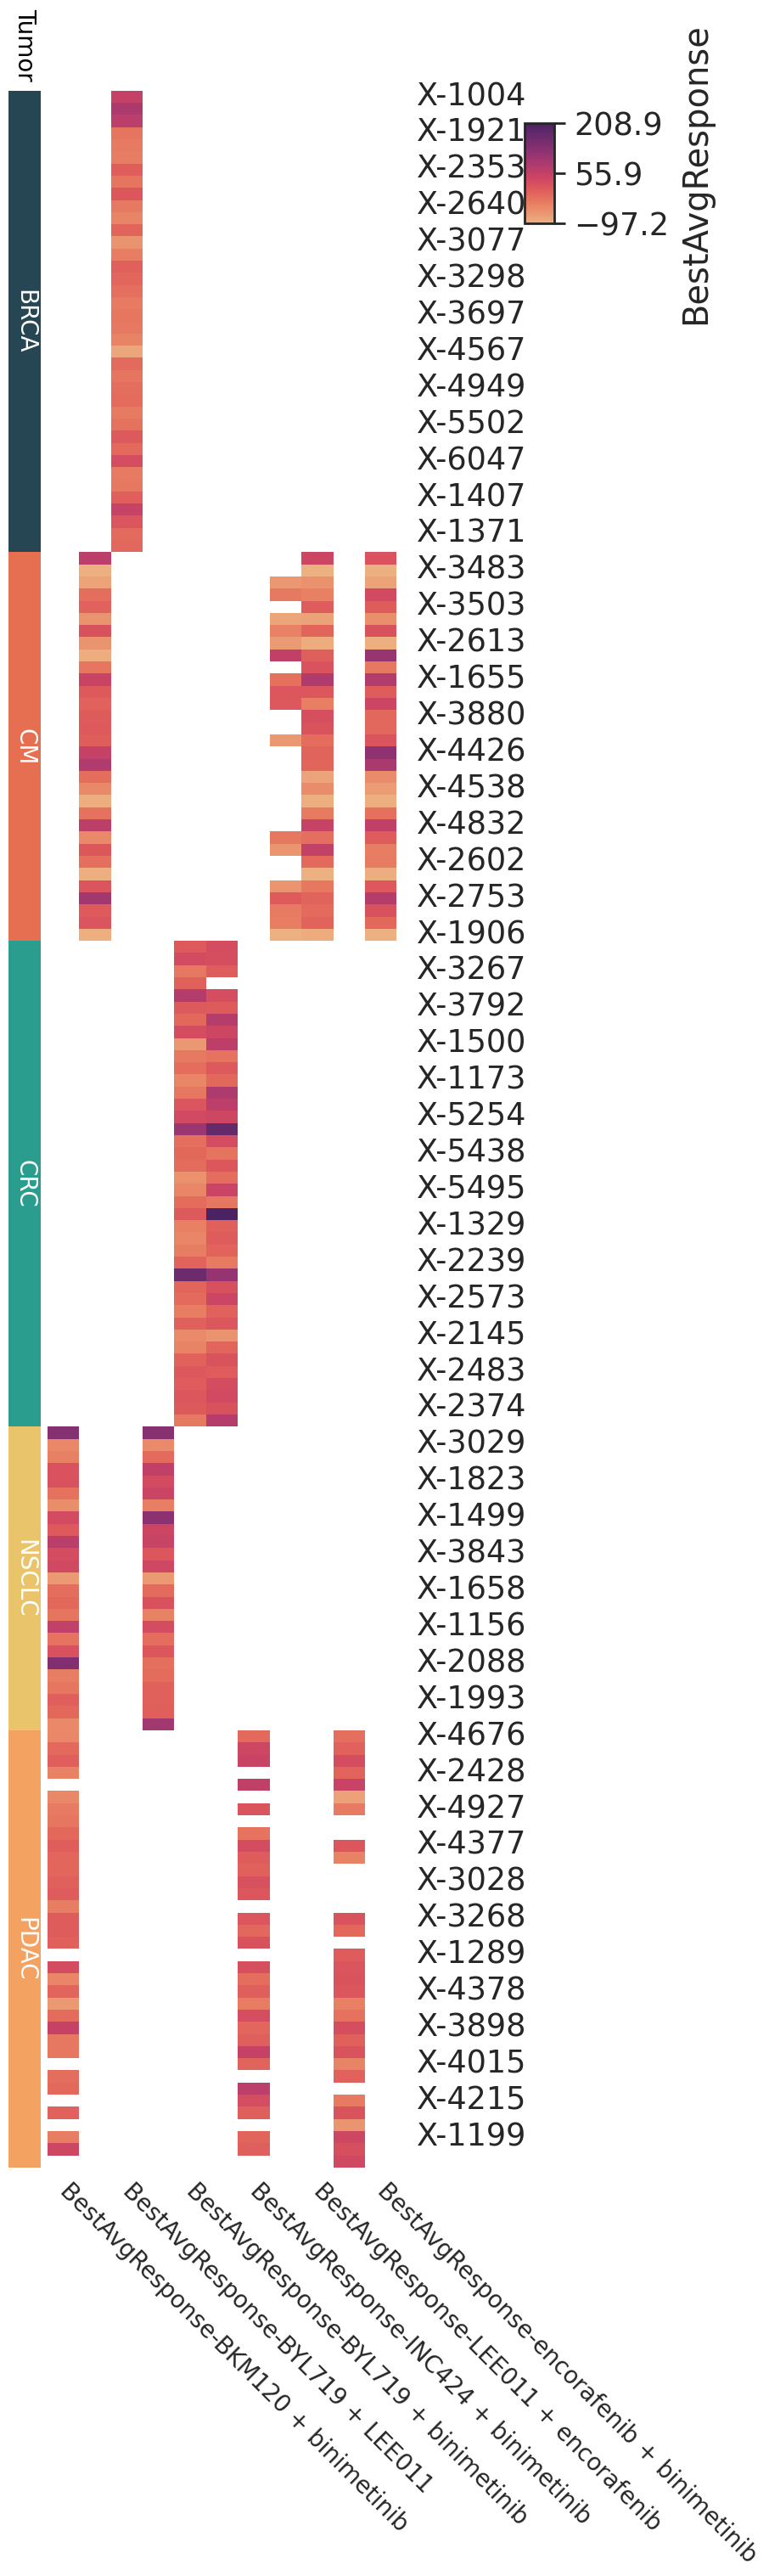

In [ ]:
import PyComplexHeatmap as pch

plot_data = X_metadata[["Model", "Treatment", "BestAvgResponse"]]
plot_data = pd.pivot_table(plot_data, values=["BestAvgResponse"], index="Model", columns="Treatment")
plot_data["tumor"] = [model_to_tumor.loc[model, "Tumor Type"] for model in plot_data.index]

colors = ["#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51"]
colors_dict = {tumor:color for tumor, color in zip(plot_data["tumor"].unique(), colors)}

row_ha_left = pch.HeatmapAnnotation(
    Tumor=pch.anno_simple(plot_data.sort_values("tumor")["tumor"], colors=colors_dict,
                             add_text=True, legend=False, height=5,
                             text_kws={'color':'white', 'fontsize':10,
                                       'rotation':-90, 'horizontalalignment':'center'}),
    label_kws={'fontsize':10, 'color':'black', 'rotation':-90, 'horizontalalignment':'right'},
    label_side="top", axis=0, verbose=0
)

plt.figure(figsize=(3, 14), dpi=200)
cm = pch.ClusterMapPlotter(data=plot_data.sort_values("tumor").drop(columns=["tumor"]), 
                           left_annotation=row_ha_left,
                           col_cluster=False, 
                           row_cluster=False,
                           label="BestAvgResponse", row_dendrogram=False,
                           col_dendrogram=False, 
                           show_rownames=True, show_colnames=True,
                           cmap=sns.color_palette("flare", as_cmap=True),
                           xticklabels_kws={'labelrotation':-45, "labelsize":10, "label1On":True}
                          )

plt.savefig("../figs/fig7_pdx_data.svg", format="svg", dpi=300)
plt.show()

In [ ]:
# Keep the distributed file if it is present.
pdx_ready_path = RAW_DATA_DIR + "processed_pdx_data_ready_for_ml.pt"
if not os.path.exists(pdx_ready_path):
    torch.save({
        "X_metadata": X_metadata,
        "pdx_rnaseq_filtered": pdx_rnaseq_filtered,
        "pdx_rnaseq_filtered_hvg": pdx_rnaseq_filtered_hvg,
        "pdx_mut_filtered": pdx_mut_filtered,
        "pdx_drug_name_to_ind": pdx_drug_name_to_ind,
    }, pdx_ready_path)


# Model-level predictions

In [3]:
_, (
    X_metadata, 
    pdx_rnaseq_filtered, 
    pdx_rnaseq_filtered_hvg, 
    pdx_mut_filtered, 
    pdx_cnv_filtered,
    pdx_drug_name_to_ind,
) = zip(*torch.load(RAW_DATA_DIR+"processed_pdx_data_ready_for_ml.pt").items())

Check drug embeddings PCA explained variance ratio

In [8]:
temp = torch.load(BASE_DIR+"model_output/DrugBank/split_by_pairs/all_train_seed42/drugbank_all_metadata_drug_embeddings_full.pt")
print(temp.shape)
pca = PCA(random_state=42)
temp_pca = pca.fit_transform(temp.numpy())

torch.Size([21842, 128])


In [9]:
np.cumsum(pca.explained_variance_ratio_)[:25]

array([0.3085645 , 0.43257895, 0.54141515, 0.6193228 , 0.6719275 ,
       0.71169657, 0.74754333, 0.7790435 , 0.80754215, 0.8319893 ,
       0.8534233 , 0.87335664, 0.8890654 , 0.9032389 , 0.91481024,
       0.9246338 , 0.93363726, 0.94134974, 0.9480778 , 0.95442367,
       0.9598155 , 0.965017  , 0.96891916, 0.9725457 , 0.9757751 ],
      dtype=float32)

## Leave-one-drug-pair-out

### Prepare data

#### PCA for RNA-seq

In [10]:
pca = PCA(random_state=42)
pdx_rnaseq_filtered_pca = pca.fit_transform(pdx_rnaseq_filtered.to_df().values)
np.cumsum(pca.explained_variance_ratio_)[:25]

array([0.20456293, 0.27806612, 0.33394618, 0.37466878, 0.40773538,
       0.43215564, 0.45508788, 0.47449173, 0.4909379 , 0.5064853 ,
       0.52025635, 0.53301335, 0.54513648, 0.55610332, 0.56642723,
       0.5760057 , 0.58490698, 0.59371104, 0.60209409, 0.61036127,
       0.61765863, 0.62470353, 0.63158453, 0.63826123, 0.64479181])

In [11]:
np.cumsum(pca.explained_variance_ratio_)[:100]

array([0.20456293, 0.27806612, 0.33394618, 0.37466878, 0.40773538,
       0.43215564, 0.45508788, 0.47449173, 0.4909379 , 0.5064853 ,
       0.52025635, 0.53301335, 0.54513648, 0.55610332, 0.56642723,
       0.5760057 , 0.58490698, 0.59371104, 0.60209409, 0.61036127,
       0.61765863, 0.62470353, 0.63158453, 0.63826123, 0.64479181,
       0.65102396, 0.65706577, 0.66303575, 0.66882318, 0.67429109,
       0.67972772, 0.6851195 , 0.69037516, 0.69557389, 0.70061616,
       0.70559158, 0.71045459, 0.71510319, 0.719701  , 0.72420534,
       0.72852671, 0.73276673, 0.73699032, 0.74117   , 0.74531611,
       0.74933756, 0.75332909, 0.75721741, 0.76102502, 0.7647917 ,
       0.76848939, 0.77216682, 0.77578286, 0.77939621, 0.78283689,
       0.78625796, 0.78961224, 0.79295686, 0.79624178, 0.79946912,
       0.80268897, 0.80581508, 0.80892953, 0.81202568, 0.8150646 ,
       0.81808892, 0.82110103, 0.82402749, 0.82690203, 0.82975883,
       0.83258079, 0.83537611, 0.83814229, 0.84087781, 0.84355

In [15]:
np.cumsum(pca.explained_variance_ratio_)[:60]

array([0.20456293, 0.27806612, 0.33394618, 0.37466878, 0.40773538,
       0.43215564, 0.45508788, 0.47449173, 0.4909379 , 0.5064853 ,
       0.52025635, 0.53301335, 0.54513648, 0.55610332, 0.56642723,
       0.5760057 , 0.58490698, 0.59371104, 0.60209409, 0.61036127,
       0.61765863, 0.62470353, 0.63158453, 0.63826123, 0.64479181,
       0.65102396, 0.65706577, 0.66303575, 0.66882318, 0.67429109,
       0.67972772, 0.6851195 , 0.69037516, 0.69557389, 0.70061616,
       0.70559158, 0.71045459, 0.71510319, 0.719701  , 0.72420534,
       0.72852671, 0.73276673, 0.73699032, 0.74117   , 0.74531611,
       0.74933756, 0.75332909, 0.75721741, 0.76102502, 0.7647917 ,
       0.76848939, 0.77216682, 0.77578286, 0.77939621, 0.78283689,
       0.78625796, 0.78961224, 0.79295686, 0.79624178, 0.79946912])

In [ ]:
pdx_rnaseq_filtered_pca_80 = pdx_rnaseq_filtered_pca[:, :60]
pdx_rnaseq_filtered_pca_90 = pdx_rnaseq_filtered_pca[:, :100]
pdx_rnaseq_filtered_pca = pdx_rnaseq_filtered_pca[:, :25]

#### MCA for Mutations

In [17]:
pdx_mut_filtered = pdx_mut_filtered.loc[:, (pdx_mut_filtered != 0).sum(0) > 2]
mca = prince.MCA(n_components=100, n_iter=10, check_input=True, copy=False, engine="sklearn", random_state=42, one_hot=True)
pdx_mut_filtered_mca = mca.fit_transform(pdx_mut_filtered)
mca.eigenvalues_summary.iloc[:25, :]

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.151,15.08%,15.08%
1,0.046,4.64%,19.71%
2,0.045,4.45%,24.17%
3,0.037,3.69%,27.85%
4,0.034,3.40%,31.26%
5,0.033,3.35%,34.60%
6,0.030,2.98%,37.58%
7,0.026,2.59%,40.17%
8,0.025,2.51%,42.68%


In [18]:
mca.eigenvalues_summary.iloc[:50, :]

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.151,15.08%,15.08%
1,0.046,4.64%,19.71%
2,0.045,4.45%,24.17%
3,0.037,3.69%,27.85%
4,0.034,3.40%,31.26%
5,0.033,3.35%,34.60%
6,0.030,2.98%,37.58%
7,0.026,2.59%,40.17%
8,0.025,2.51%,42.68%


In [21]:
mca.eigenvalues_summary.iloc[:80, :]

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.151,15.08%,15.08%
1,0.046,4.64%,19.71%
2,0.045,4.45%,24.17%
3,0.037,3.69%,27.85%
4,0.034,3.40%,31.26%
...,...,...,...
75,0.003,0.29%,90.18%
76,0.003,0.28%,90.46%
77,0.003,0.28%,90.74%


In [22]:
pdx_mut_filtered_mca_80 = pdx_mut_filtered_mca.iloc[:, :50]
pdx_mut_filtered_mca_90 = pdx_mut_filtered_mca.iloc[:, :80]
pdx_mut_filtered_mca = pdx_mut_filtered_mca.iloc[:, :25]

#### Prepare all patient features

In [23]:
assert (pdx_rnaseq_filtered.obs.index.values != pdx_mut_filtered_mca.index.values).sum() == 0

pdx_rnaseq_model_to_ind = {model: ind for ind, model in enumerate(pdx_rnaseq_filtered.obs.index)}

X_model_rnaseq_pca = pdx_rnaseq_filtered_pca[[pdx_rnaseq_model_to_ind[model] for model in X_metadata["Model"]], :]
X_model_rnaseq_pca_80 = pdx_rnaseq_filtered_pca_80[[pdx_rnaseq_model_to_ind[model] for model in X_metadata["Model"]], :]
X_model_rnaseq_pca_90 = pdx_rnaseq_filtered_pca_90[[pdx_rnaseq_model_to_ind[model] for model in X_metadata["Model"]], :]

X_model_mut_mca = pdx_mut_filtered_mca.values[[pdx_rnaseq_model_to_ind[model] for model in X_metadata["Model"]], :]
X_model_mut_mca_80 = pdx_mut_filtered_mca_80.values[[pdx_rnaseq_model_to_ind[model] for model in X_metadata["Model"]], :]
X_model_mut_mca_90 = pdx_mut_filtered_mca_90.values[[pdx_rnaseq_model_to_ind[model] for model in X_metadata["Model"]], :]

In [24]:
torch.save({
    "pdx_rnaseq_model_to_ind": pdx_rnaseq_model_to_ind,
    "X_model_rnaseq_pca": X_model_rnaseq_pca,
    "X_model_rnaseq_pca_80": X_model_rnaseq_pca_80,
    "X_model_rnaseq_pca_90": X_model_rnaseq_pca_90,
    "X_model_mut_mca": X_model_mut_mca,
    "X_model_mut_mca_80": X_model_mut_mca_80,
    "X_model_mut_mca_90": X_model_mut_mca_90,
}, RAW_DATA_DIR+"processed_pdx_data_ready_for_ml_splitted.pt")

### Regression

#### Load data

In [4]:
_, (
    pdx_rnaseq_model_to_ind, 
    X_model_rnaseq_pca, 
    X_model_rnaseq_pca_80,
    X_model_rnaseq_pca_90,
    X_model_mut_mca, 
    X_model_mut_mca_80,
    X_model_mut_mca_90
) = zip(*torch.load(RAW_DATA_DIR+"processed_pdx_data_ready_for_ml_splitted.pt").items())

Outcomes: `BestAvgResponse` (drug response) and `TimeToDouble` (progression-free survival)

In [ ]:
TARGETS = ["BestAvgResponse", "TimeToDouble"]

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for ax, target in zip(axes, TARGETS):
    ax.hist(X_metadata[target].values, ec="white", bins=20)
    ax.set_title(f"y_cont = {target}")
plt.show()


In [ ]:
from scipy.stats import kendalltau, pearsonr

def perm_pvalue(pred, y, n_perm=10000, seed=0):
    """Two-sided permutation p for Kendall tau: shuffle the held-out labels.
    Robust to ties and small n. Floored at 1/(n_perm+1)."""
    rng = np.random.default_rng(seed)
    obs = abs(kendalltau(pred, y).statistic)
    null = np.array([abs(kendalltau(pred, rng.permutation(y)).statistic) for _ in range(n_perm)])
    return (np.sum(null >= obs) + 1) / (n_perm + 1)

def bh_fdr(p):
    """Benjamini-Hochberg q-values."""
    p = np.asarray(p, float); n = p.size
    order = np.argsort(p); ranked = p[order]
    q = np.minimum.accumulate((ranked * n / np.arange(1, n + 1))[::-1])[::-1]
    out = np.empty(n); out[order] = np.clip(q, 0, 1)
    return out

def leave_one_pair_out(target):
    y_cont = X_metadata[target].values

    all_drug_pairs_patient_scores = {}
    all_pearsonr_perfs = {}
    all_spearmanr_perfs = {}
    all_kendalltau_perfs = {}
    all_ensemble_preds = {}
    all_test_labels = {}

    for drug_pair_test in X_metadata["Treatment"].unique():
        test_indicator_leave_one_drug_pair_out = X_metadata["Treatment"].values == drug_pair_test
        train_indicator_leave_one_drug_pair_out = ~test_indicator_leave_one_drug_pair_out
    
        y_cont_train = y_cont[train_indicator_leave_one_drug_pair_out]
        y_cont_test = y_cont[test_indicator_leave_one_drug_pair_out]
    
        print(drug_pair_test)
    
        drug_pair_patient_scores = []
        pearsonr_perfs = []
        spearmanr_perfs = []
        kendalltau_perfs = []
        
        for run_name in [
            "all_train_seed42",
            "all_train_seed99",
            "all_train_seed1",
            "all_train_seed2",
            "all_train_seed0"
        ]:
            print(f"\tWorking on ckpt: {run_name}")
            drug_embeds = torch.load(BASE_DIR+f"model_output/DrugBank/split_by_pairs/{run_name}/drugbank_all_metadata_drug_embeddings_full.pt")[:drug_metadata[~drug_metadata["node_id"].isna()].index.max()+1]
            pca = PCA(random_state=42)
            drug_embeds_pca = pca.fit_transform(drug_embeds.numpy())
            drug_embeds_pca = drug_embeds_pca[:, :25]  # already explains 95% variance

            X_drug_1_embeds_pca = drug_embeds_pca[X_metadata["drug_1_ind"].values]
            X_drug_2_embeds_pca = drug_embeds_pca[X_metadata["drug_2_ind"].values]
            X_drug_embeds_pca_max = np.max(np.stack([X_drug_1_embeds_pca, X_drug_2_embeds_pca], axis=-1), axis=-1)

            X_full = np.concatenate([
                X_model_rnaseq_pca, 
                X_model_mut_mca, 
                X_drug_embeds_pca_max, 
            ], axis=1)

            X_full_test = X_full[test_indicator_leave_one_drug_pair_out]
            X_full_train = X_full[train_indicator_leave_one_drug_pair_out]

            for seed in [0, 1, 2, 42, 99]:
                print(f"\t\tSeed {str(seed)}")
                clf = RandomForestRegressor(
                    n_estimators=1000, criterion="friedman_mse", max_depth=None, min_samples_split=2, max_features=1.0,
                    n_jobs=-1, random_state=seed)
            
                clf.fit(X_full_train, y_cont_train)
                preds_test = clf.predict(X_full_test)
            
                drug_pair_patient_scores.append(preds_test)
                pearsonr_perfs.append(pearsonr(preds_test, y_cont_test))
                spearmanr_perfs.append(spearmanr(preds_test, y_cont_test))
                kendalltau_perfs.append(kendalltau(preds_test, y_cont_test))
    
        # Ensemble = mean prediction across the 25 fits (5 Madrigal ckpts x 5 RF seeds).
        preds_stack = np.stack(drug_pair_patient_scores, axis=0)      # (n_fits, n_test)
        ensemble_pred = preds_stack.mean(axis=0)
        all_ensemble_preds[drug_pair_test] = ensemble_pred
        all_test_labels[drug_pair_test] = y_cont_test
        all_drug_pairs_patient_scores[drug_pair_test] = dict(zip(X_metadata["Model"][test_indicator_leave_one_drug_pair_out].values, 
                                                                 ensemble_pred))
        all_pearsonr_perfs[drug_pair_test] = pearsonr_perfs
        all_spearmanr_perfs[drug_pair_test] = spearmanr_perfs
        all_kendalltau_perfs[drug_pair_test] = kendalltau_perfs
    return {
        "patient_scores": all_drug_pairs_patient_scores,
        "pearsonr": all_pearsonr_perfs,
        "spearmanr": all_spearmanr_perfs,
        "kendalltau": all_kendalltau_perfs,
        "ensemble_preds": all_ensemble_preds,
        "test_labels": all_test_labels,
    }

lopo_results = {target: leave_one_pair_out(target) for target in TARGETS}


#### response, RF

In [15]:
#   n            - held-out PDX models for this drug pair
#   tau_ensemble - Kendall tau of the mean-over-fits prediction vs held-out truth
#   tau_mean/sd  - mean and SD of Kendall tau across the 25 fits
#   p_ensemble   - asymptotic Kendall p for that single test
#   p_perm       - permutation p, robust to ties/small n (floored at 1/(n_perm+1))
#   q_BH         - Benjamini-Hochberg FDR across the drug pairs
res = lopo_results["BestAvgResponse"]
rows = {}
for pair, ens in res["ensemble_preds"].items():
    y = res["test_labels"][pair]
    tau_ens, p_ens = kendalltau(ens, y)
    taus = np.array([vv.statistic for vv in res["kendalltau"][pair]])
    rows[pair] = (len(y), tau_ens, taus.mean(), taus.std(), p_ens, perm_pvalue(ens, y))

perf_table = pd.DataFrame(
    rows, index=["n", "tau_ensemble", "tau_mean", "tau_sd", "p_ensemble", "p_perm"]
).T
perf_table["q_BH"] = bh_fdr(perf_table["p_ensemble"].values)
perf_table["n"] = perf_table["n"].astype(int)
perf_table


,n,tau_ensemble,tau_mean,tau_sd,p_ensemble,p_perm,q_BH
BYL719 + LEE011,38,0.095306,0.098492,0.035262,3.996102e-01,0.405759,0.399610
BYL719 + encorafenib,39,0.333333,0.332578,0.009940,2.808762e-03,0.002900,0.006094
BYL719 + binimetinib,40,0.323077,0.320000,0.014721,3.324093e-03,0.003000,0.006094
BKM120 + binimetinib,55,0.415488,0.412094,0.015408,7.494569e-06,0.000100,0.000027
BYL719 + LGH447,25,0.393333,0.397333,0.024148,5.412547e-03,0.005599,0.008505
abraxane + gemcitabine,28,0.259259,0.230265,0.019860,5.474241e-02,0.057394,0.066907
INC424 + binimetinib,28,0.206349,0.195556,0.036180,1.290295e-01,0.132687,0.141932
BKM120 + encorafenib,32,0.596774,0.600968,0.012466,3.019523e-07,0.000100,0.000003
LEE011 + encorafenib,32,0.508065,0.501129,0.012929,2.103566e-05,0.000200,0.000058
LEE011 + binimetinib,17,0.470588,0.452941,0.033015,7.921136e-03,0.009699,0.010892


In [16]:
all_drug_pairs_patient_scores_response_target = lopo_results["BestAvgResponse"]["patient_scores"]
torch.save(all_drug_pairs_patient_scores_response_target, "all_drug_pairs_patient_scores_response_target.pkl")

In [33]:
all_drug_pairs_patient_scores_response_target = torch.load("all_drug_pairs_patient_scores_response_target.pkl")

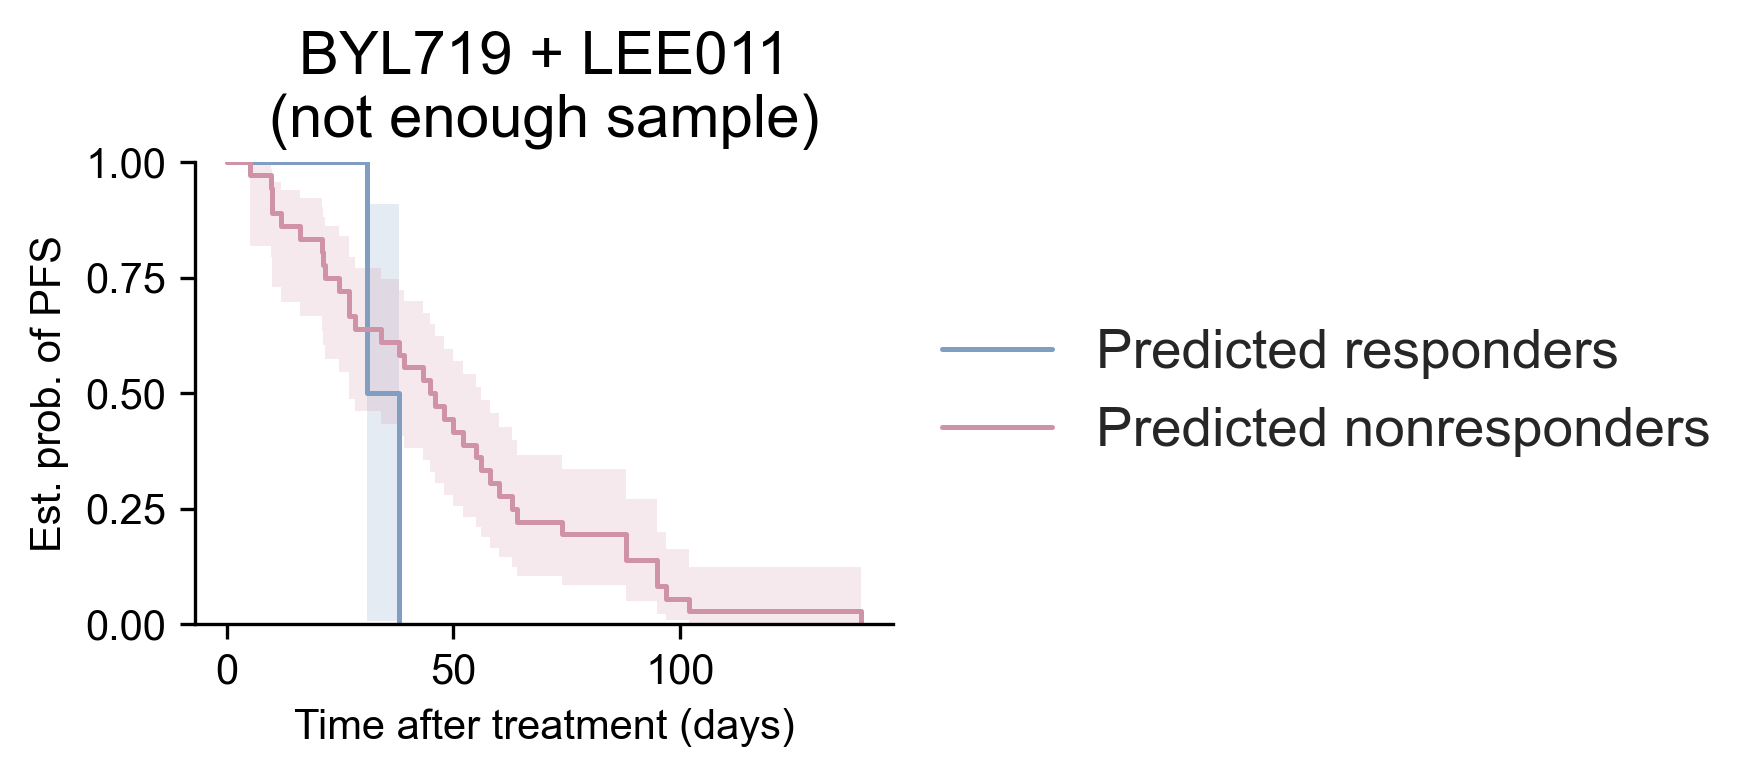

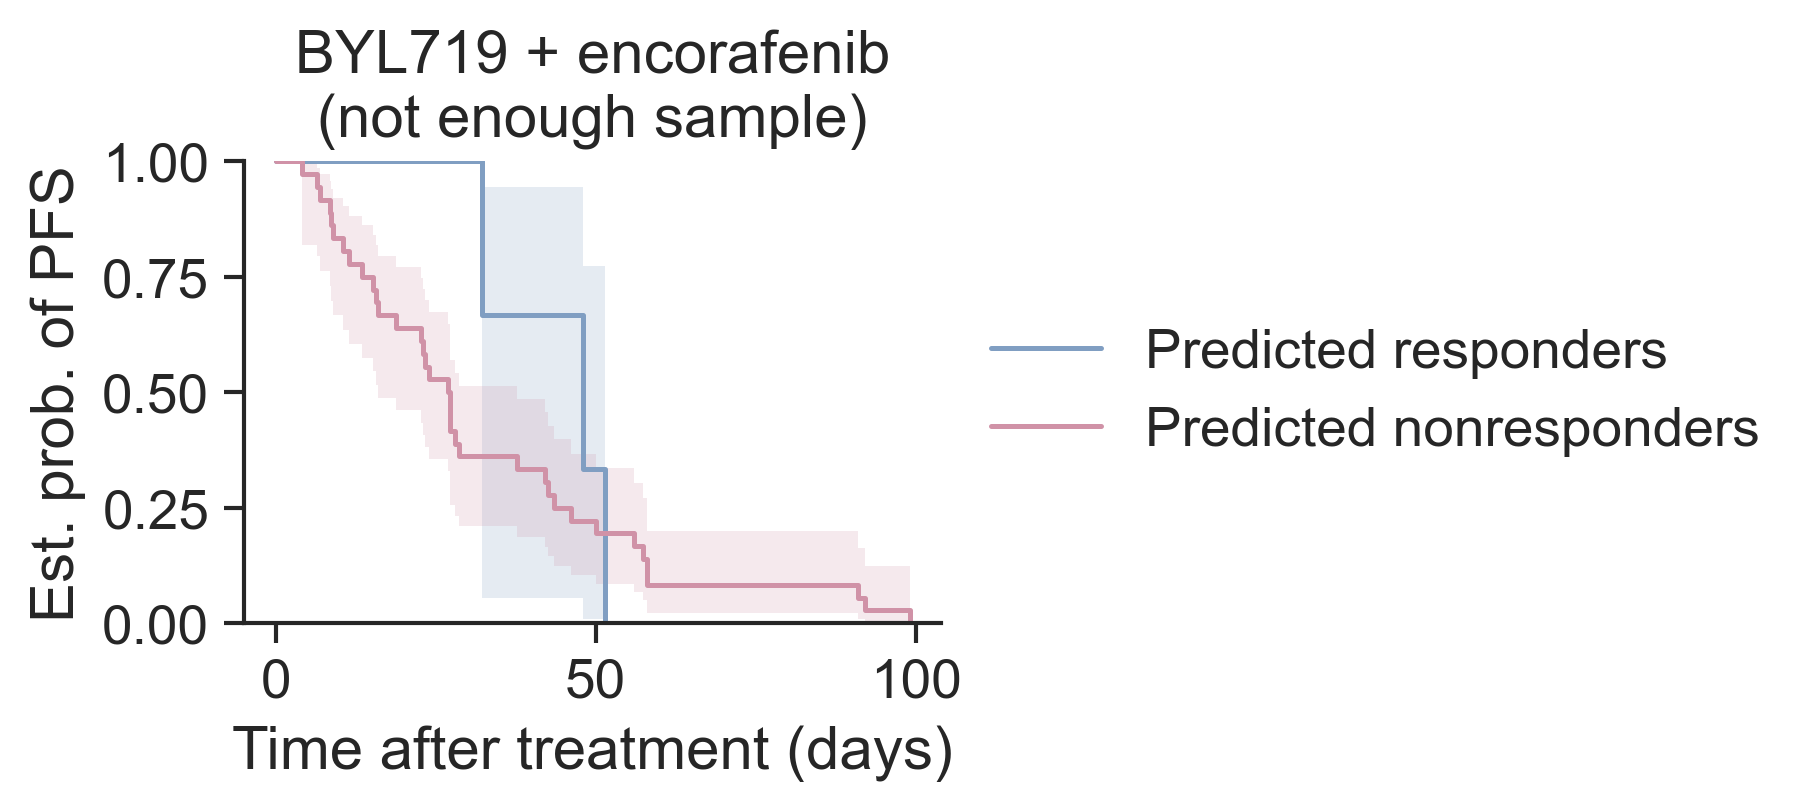

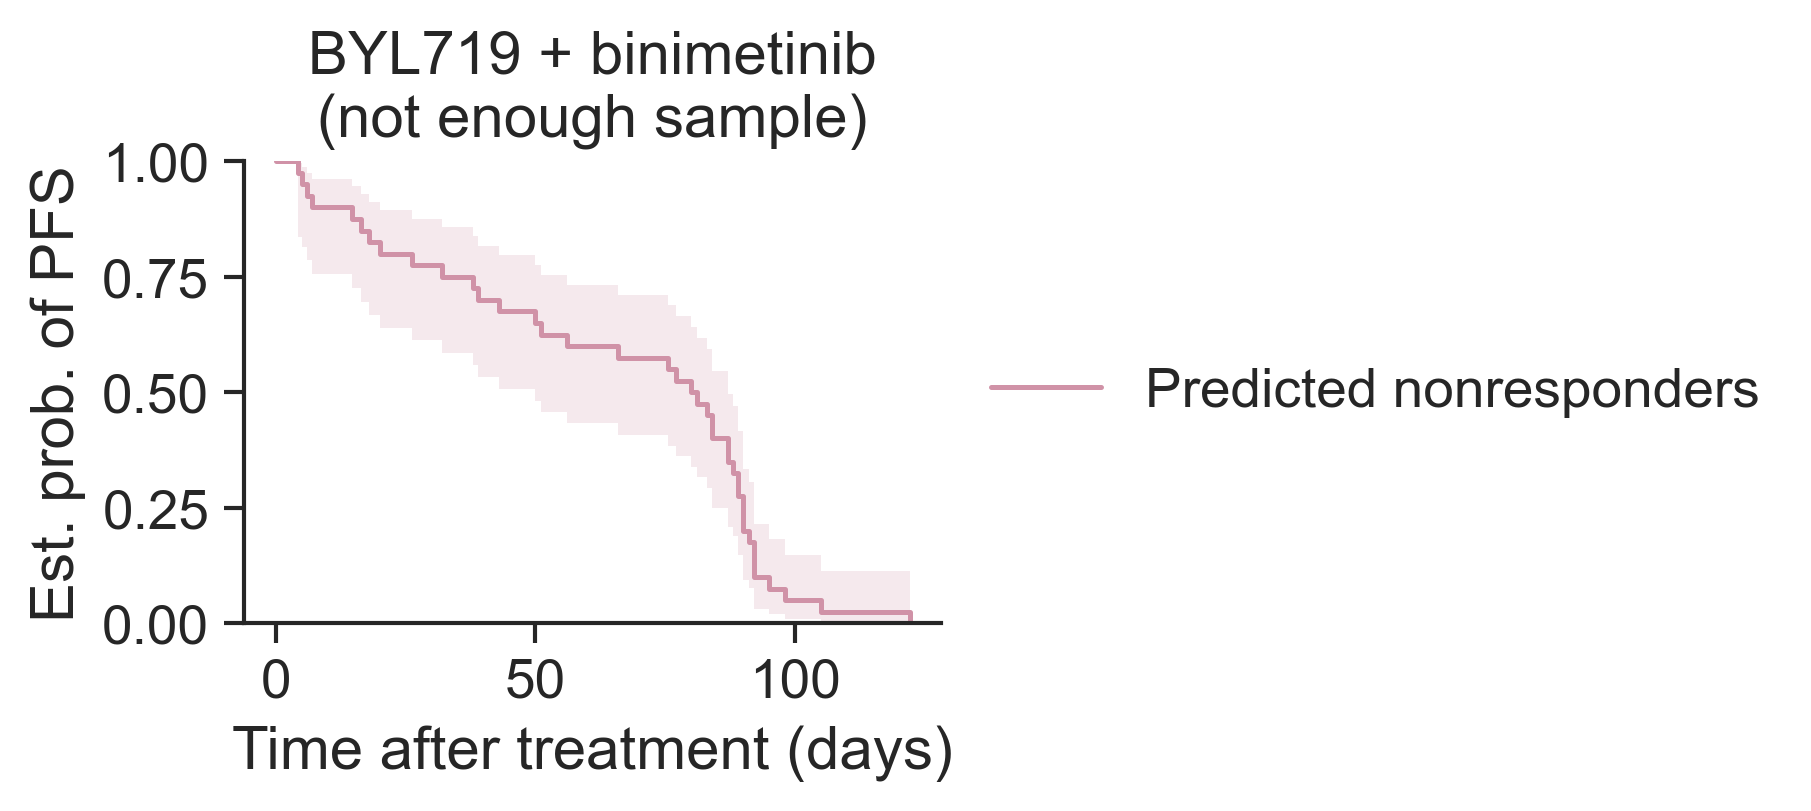

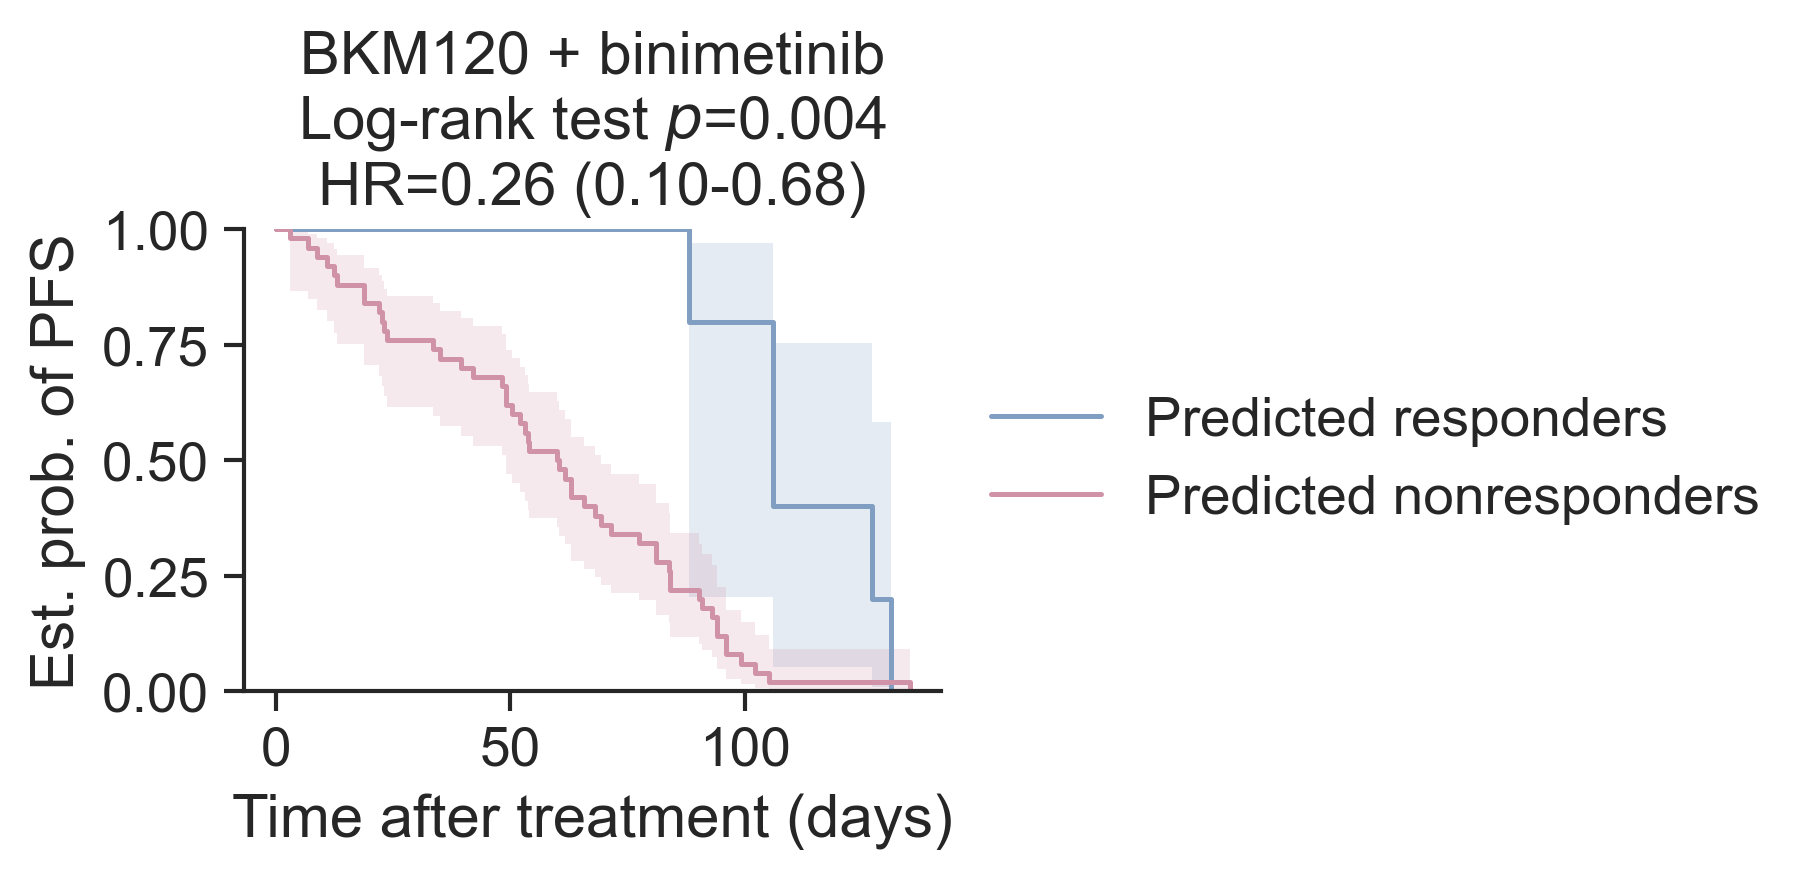

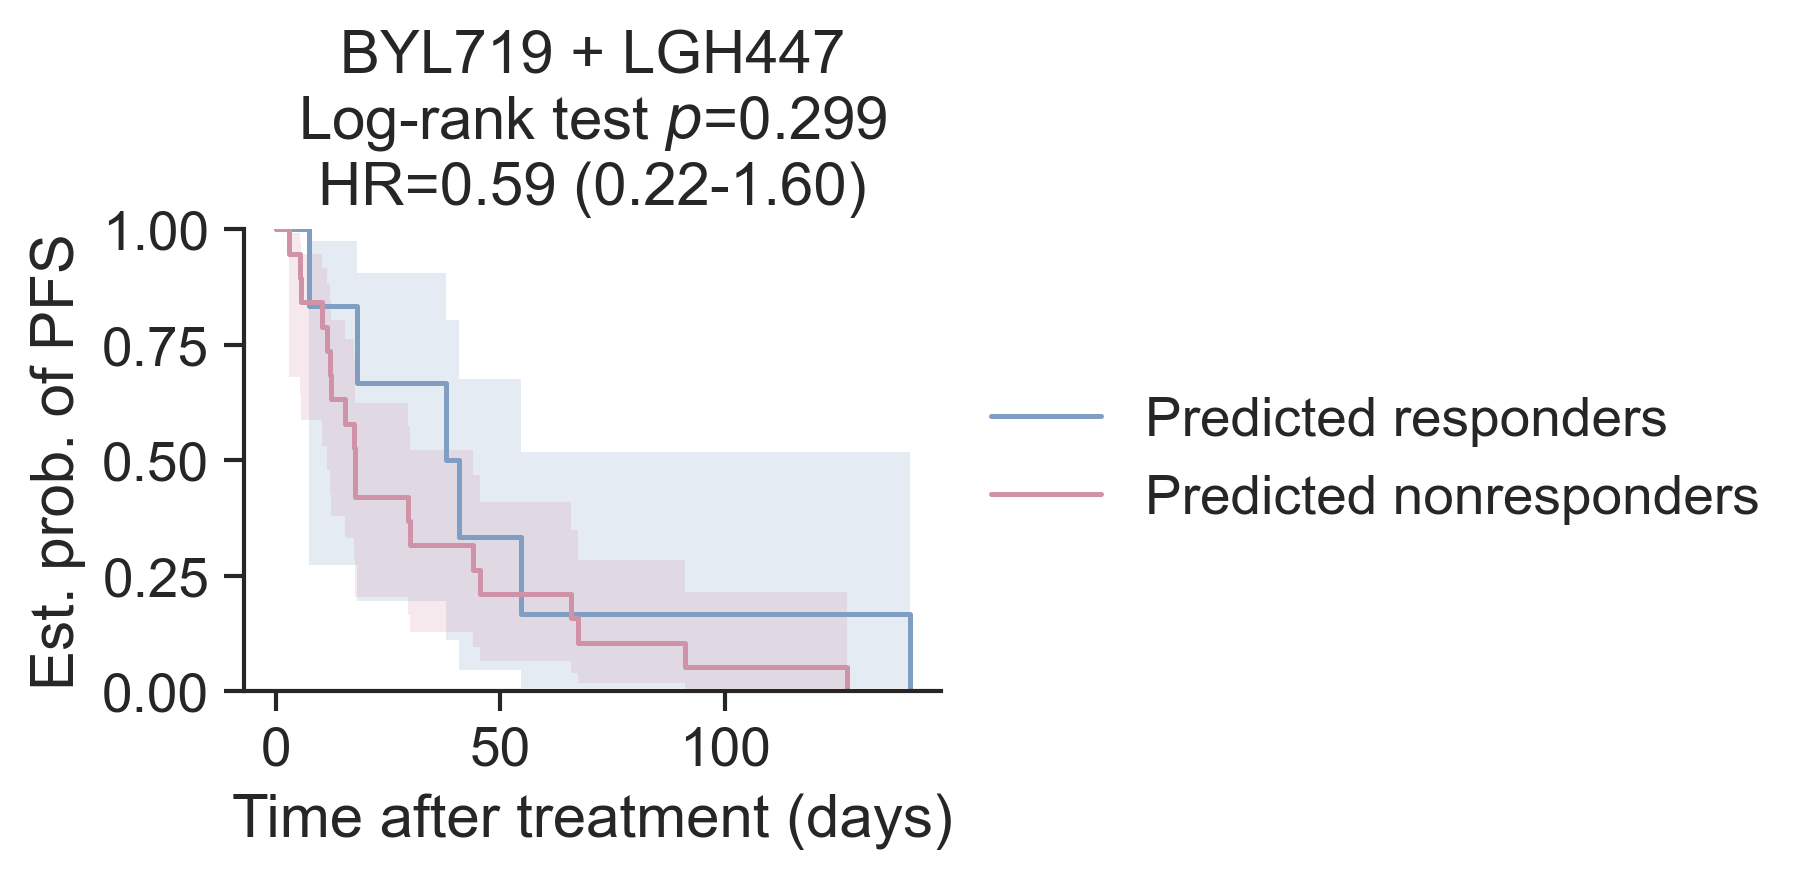

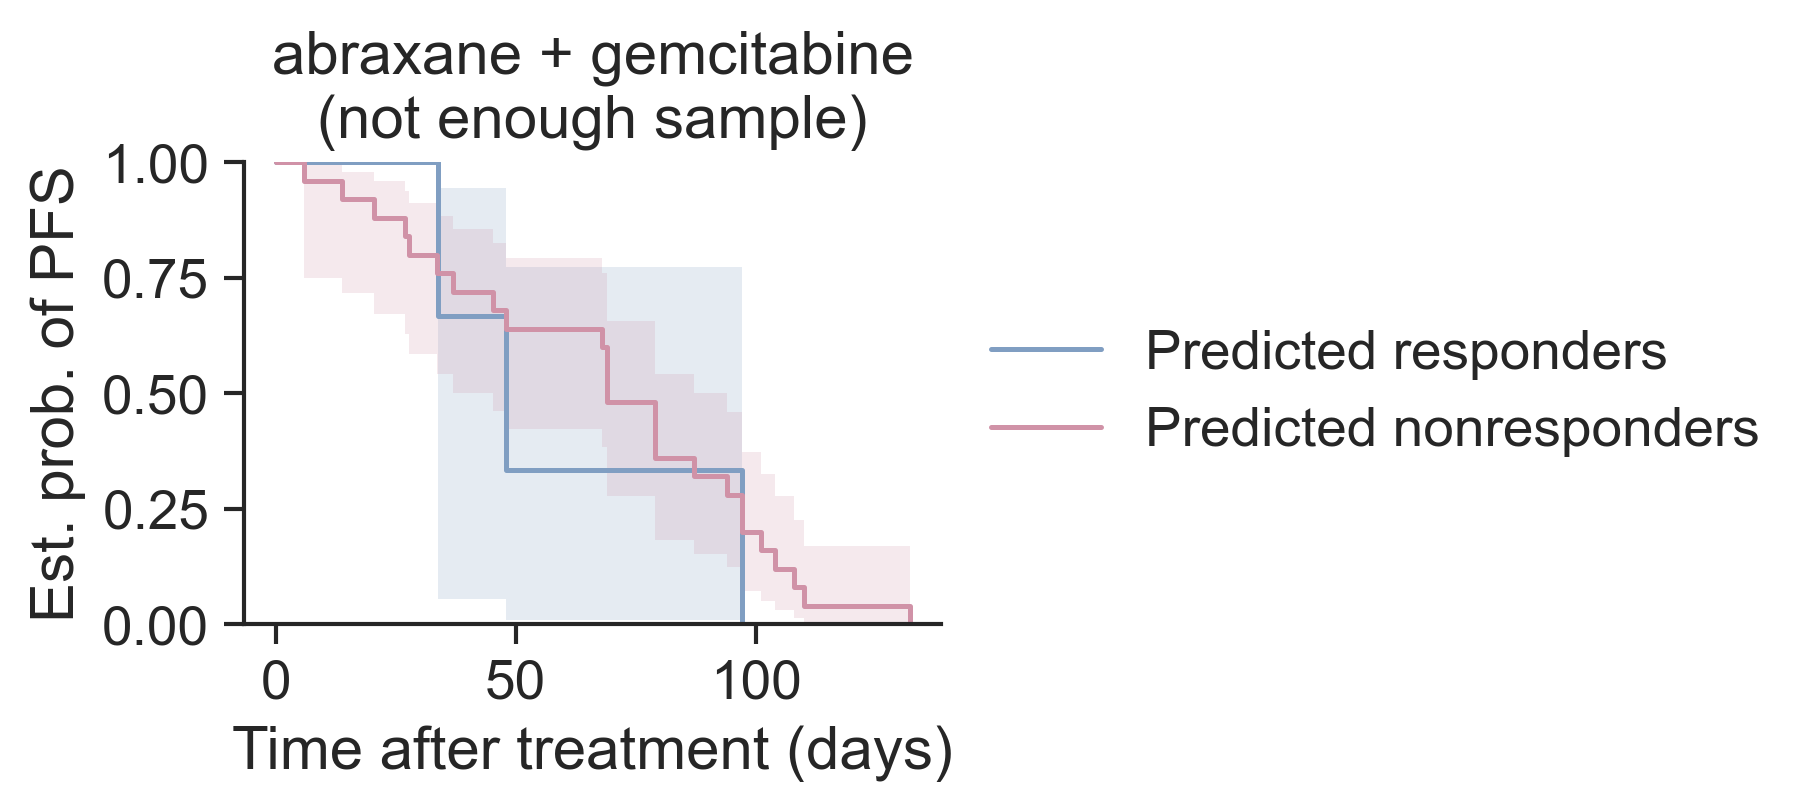

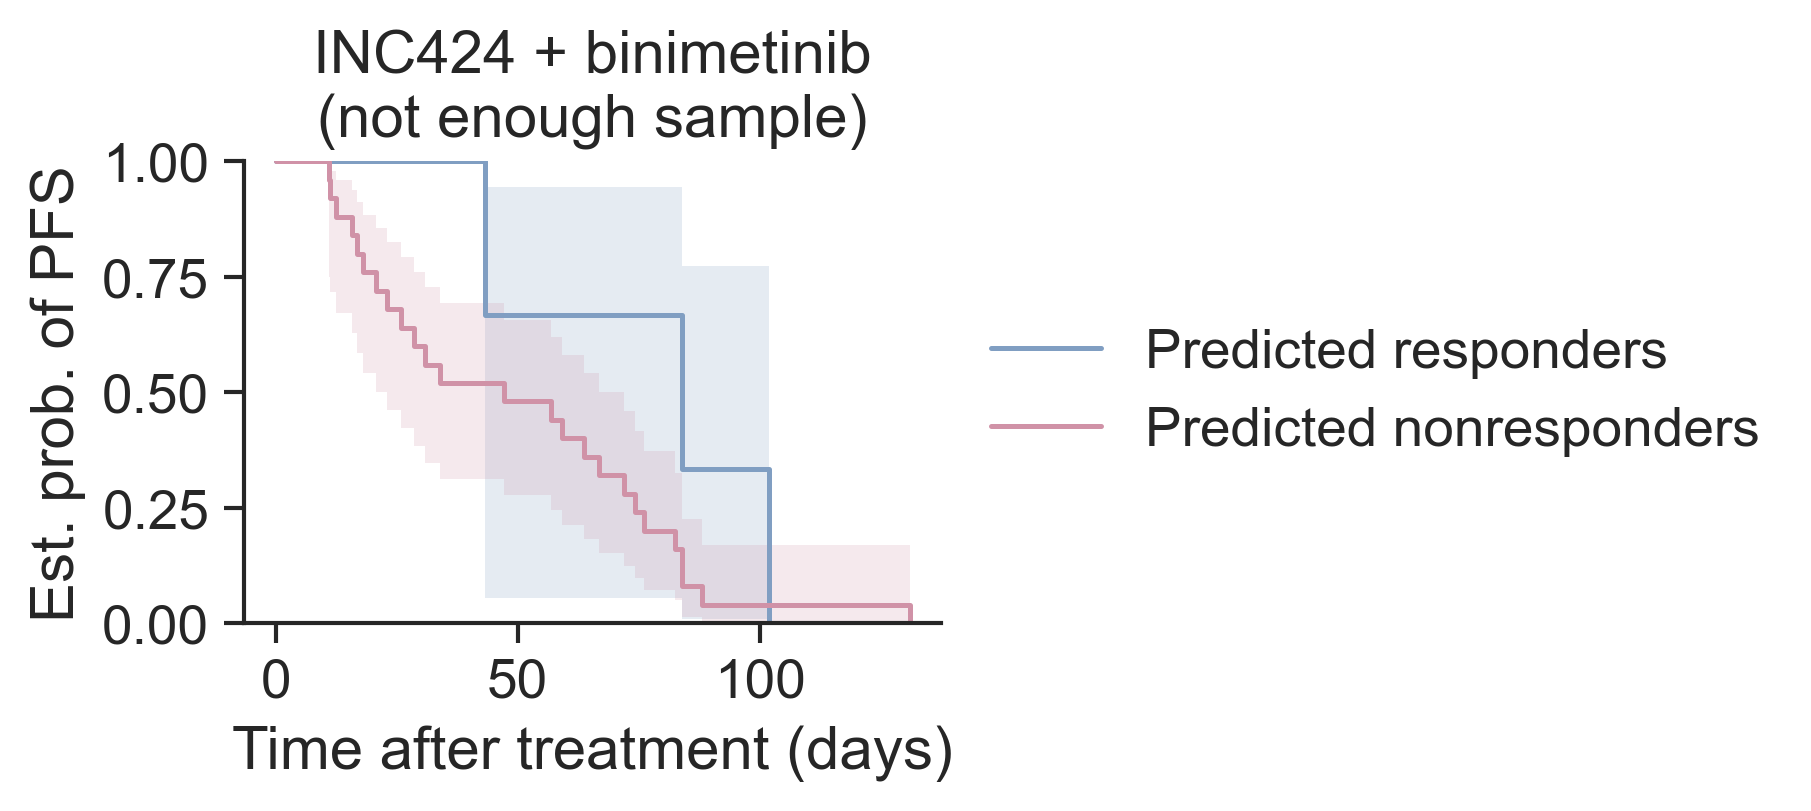

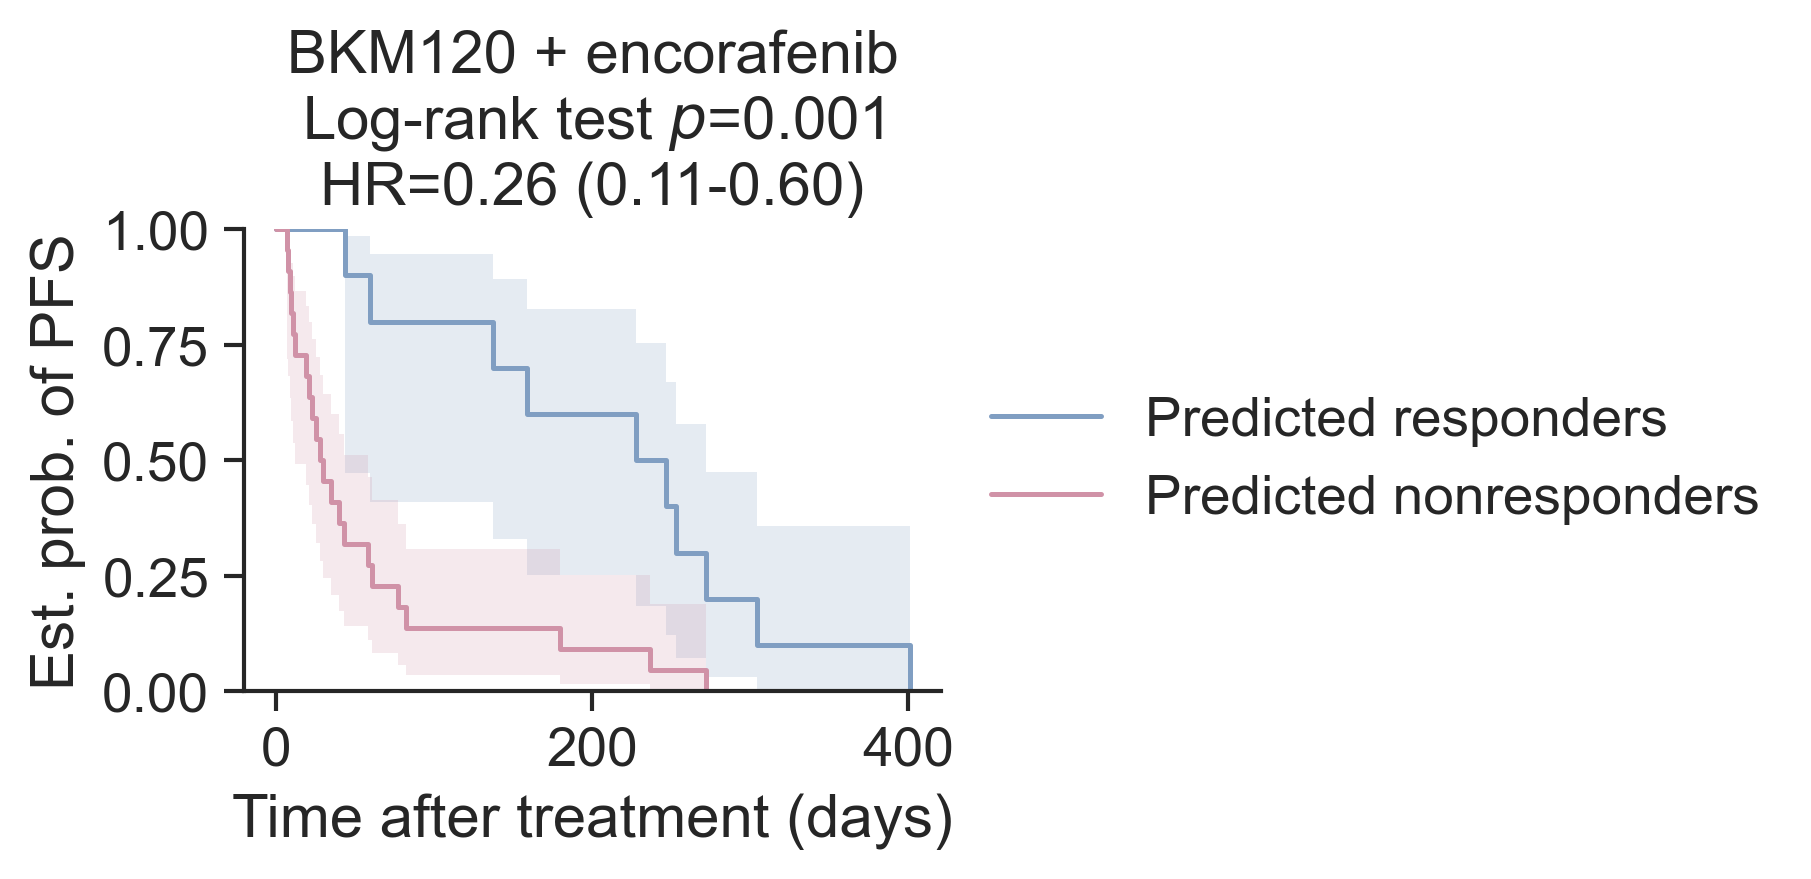

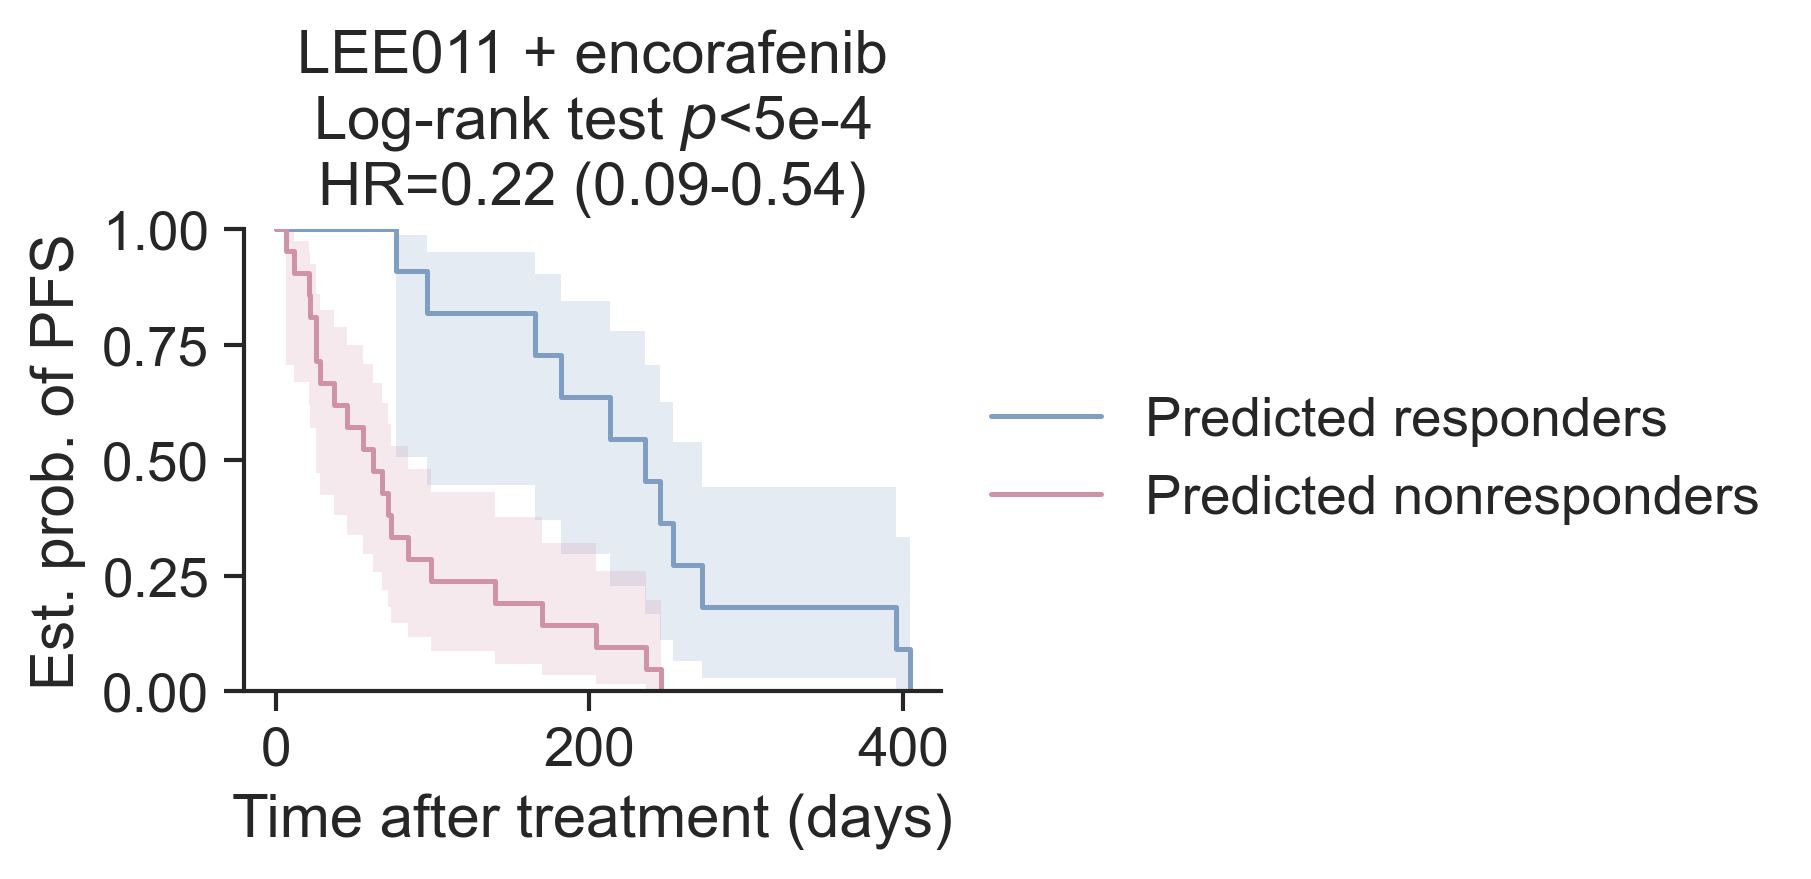

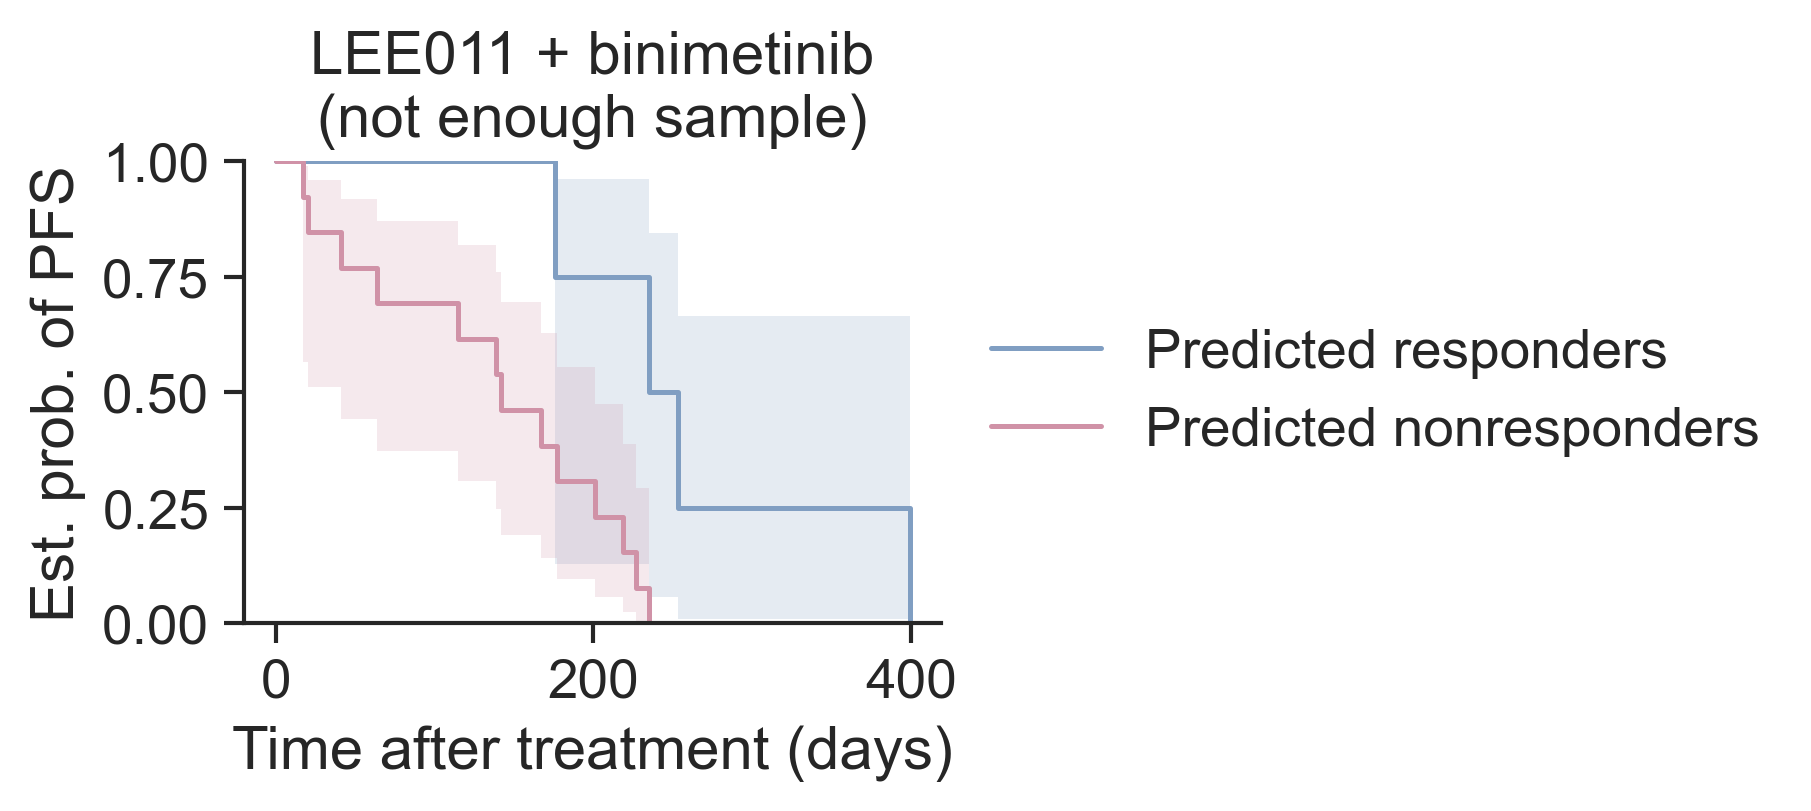

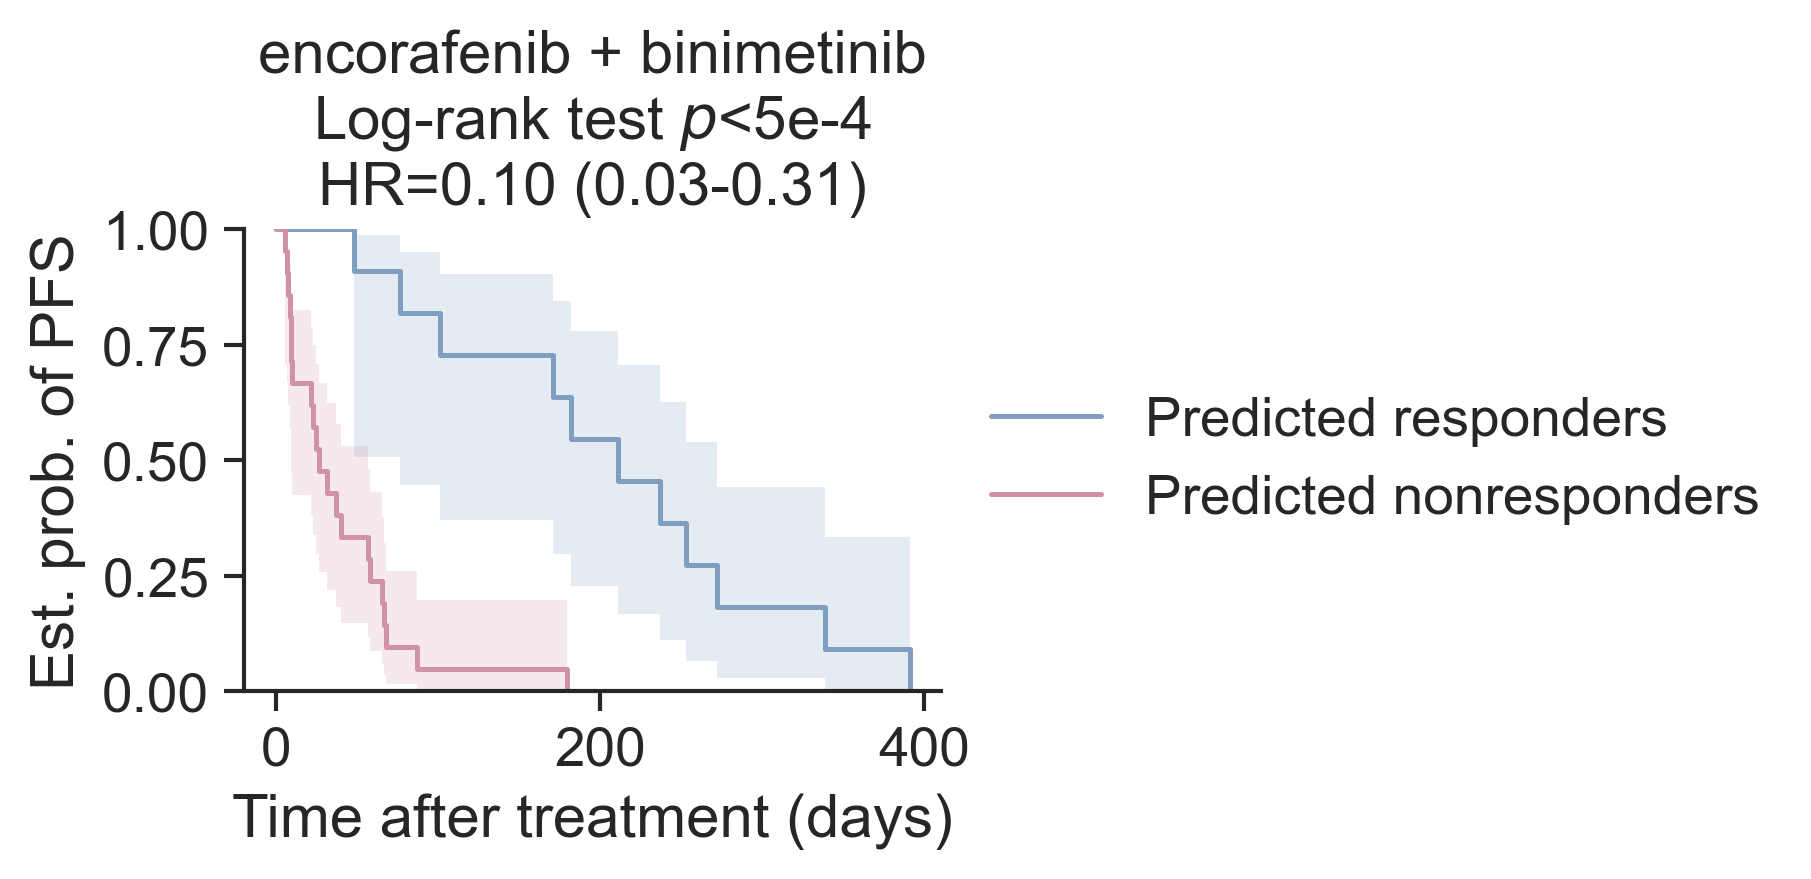

In [18]:
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

from matplotlib import font_manager as fm
arial_path = "../arial.ttf"
try:
    fm.fontManager.addfont(arial_path)
except OSError:
    pass
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

predicted_outcome = "BestAvgResponse"
pfs_col = "TimeToDouble"

for drug_pair, dct in all_drug_pairs_patient_scores_response_target.items():
    patients = list(dct.keys())
    pred_scores = np.array(list(dct.values()))
    pred_respond = pred_scores < -20
    mask = pred_respond
    pfs = X_metadata[["Model", "Treatment", pfs_col]].set_index(["Model", "Treatment"]).loc[(patients, drug_pair), pfs_col]
    
    _, ax = plt.subplots(figsize=(3, 2), dpi=300)
    sns.set(context="paper", style="ticks", font_scale=1.5)

    kmf = KaplanMeierFitter()
    if mask.sum() > 0:
        kmf.fit(durations = pfs[mask], event_observed = np.array([True] * mask.sum()), label = "Predicted responders")
        kmf.plot_survival_function(ax = ax, ci_alpha = 0.2, ci_no_lines = True, color = "#809ec2")
    if (~mask).sum() > 0:
        kmf.fit(durations = pfs[~mask], event_observed = np.array([True] * (~mask).sum()), label = "Predicted nonresponders")
        kmf.plot_survival_function(ax = ax, ci_alpha = 0.2, ci_no_lines = True, color = "#d092a7")
        
    if pred_respond.sum() >= 5 and (1 - pred_respond).sum() >= 5:
        results = logrank_test(pfs[mask], pfs[~mask], 
                               event_observed_A=np.array([True] * mask.sum()), event_observed_B=np.array([True] * (~mask).sum()))
        
        df = pd.DataFrame({
            "time": pfs,
            "event": np.ones_like(pfs, dtype=int),   # 1 = event occurred
            "group": mask.astype(int)                # 1 = mask True, 0 = mask False
        })

        cph = CoxPHFitter()
        cph.fit(df, duration_col="time", event_col="event")
        hr = cph.summary["exp(coef)"].values[0]
        hr_ci_lower_95 = cph.summary["exp(coef) lower 95%"].values[0]
        hr_ci_higher_95 = cph.summary["exp(coef) upper 95%"].values[0]
        
        if results.p_value >= 0.0005:
            plt.title(drug_pair+"\n"+r"Log-rank test $p$="+f"{results.p_value:.3f}"+"\n"+f"HR={hr:.2f} ({hr_ci_lower_95:.2f}-{hr_ci_higher_95:.2f})")
        else:
            plt.title(drug_pair+"\n"+r"Log-rank test $p$<5e-4"+"\n"+f"HR={hr:.2f} ({hr_ci_lower_95:.2f}-{hr_ci_higher_95:.2f})")

    else:
        plt.title(drug_pair+"\n(not enough sample)")
        
    plt.ylim(0, 1)
    plt.ylabel("Est. prob. of PFS")
    plt.xlabel("Time after treatment (days)")
    plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)
    sns.despine()
    
    plt.savefig(f"./fig7_pdx_survival_pr_cr_vs_pd_sd_{drug_pair}.svg", format="svg", dpi=300)
    plt.show()

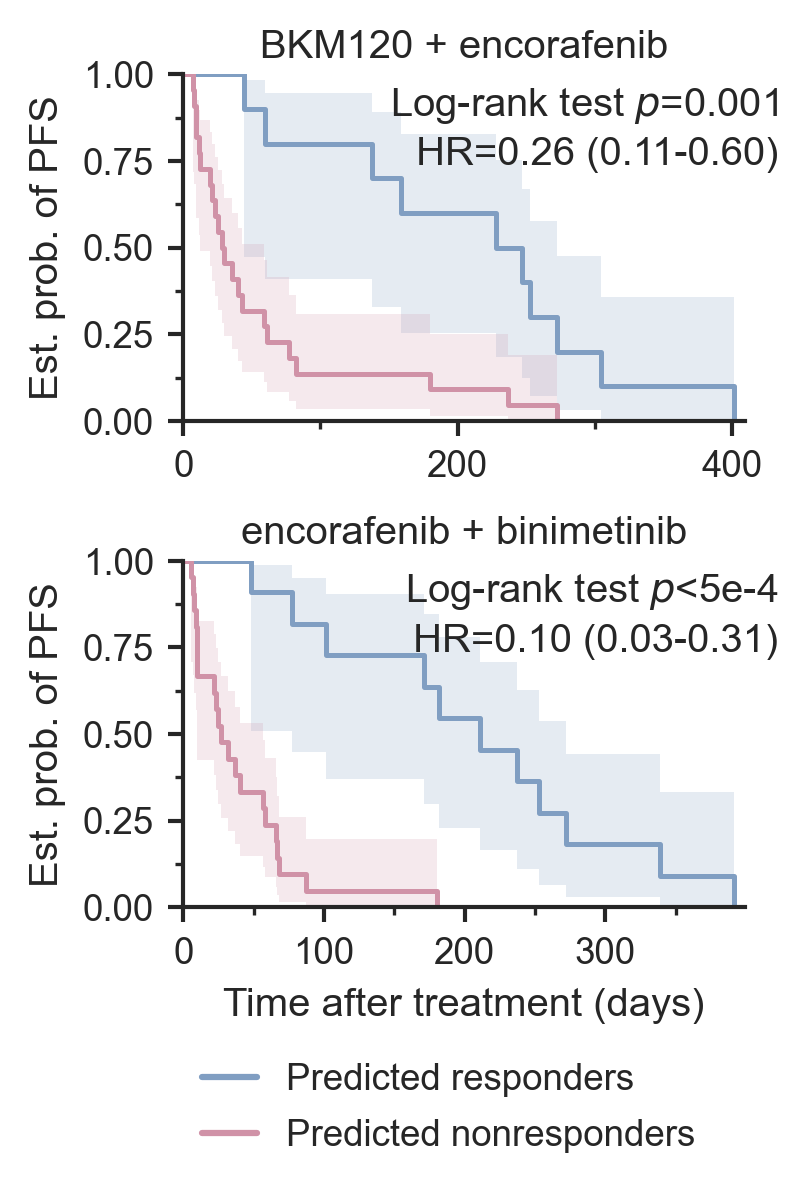

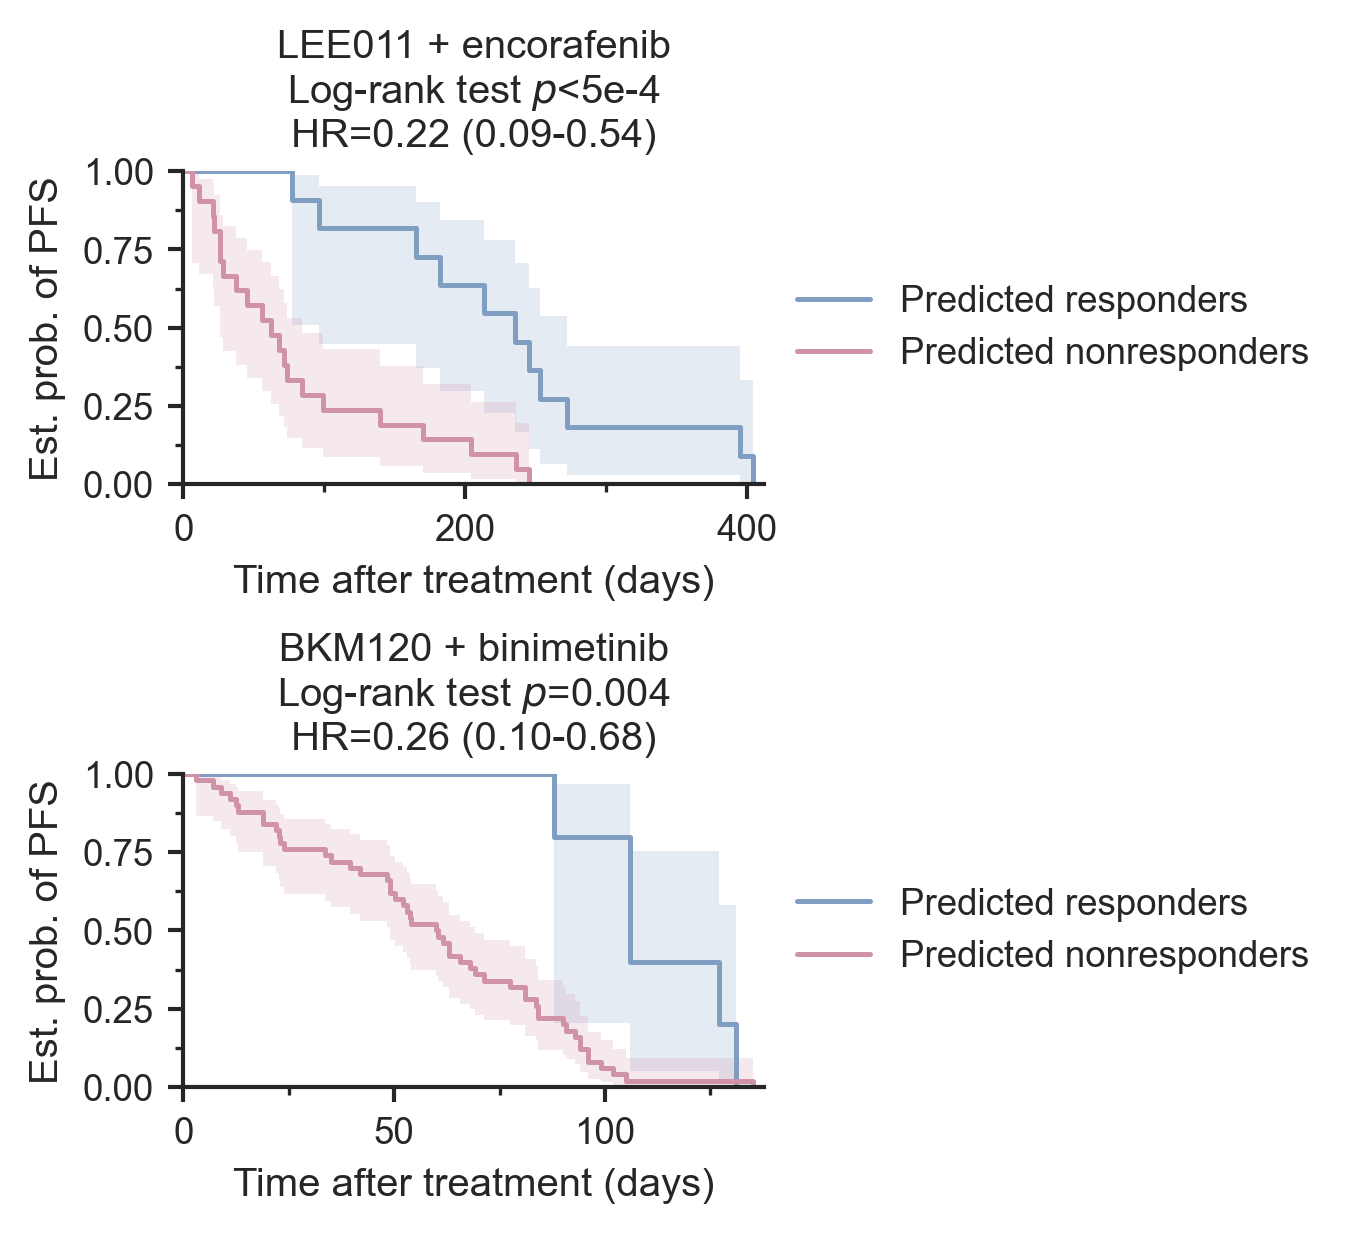

In [40]:
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
from matplotlib.lines import Line2D
from matplotlib import font_manager as fm

arial_path = "../arial.ttf"
try:
    fm.fontManager.addfont(arial_path)
except OSError:
    pass
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

predicted_outcome = "BestAvgResponse"
pfs_col = "TimeToDouble"

COLOR_RESPONDER = "#809ec2"
COLOR_NONRESPONDER = "#d092a7"

TOP_PAIRS = ["BKM120 + encorafenib", "encorafenib + binimetinib"]
OTHER_SIG_PAIRS = ["LEE011 + encorafenib", "BKM120 + binimetinib"]

def nice_step(vmax, target_n_major=4):
    """Smallest 1/2/2.5/5/10-style step that keeps major ticks at or below target_n_major."""
    for exp in range(-2, 6):
        for mant in (1, 2, 2.5, 5):
            step = mant * 10 ** exp
            if vmax / step <= target_n_major:
                return step
    return 10 ** 6

def km_panel(ax, drug_pair, show_xlabel=True, show_ylabel=True, panel_legend=False,
             stats_in_axes=False):
    dct = all_drug_pairs_patient_scores_response_target[drug_pair]
    patients = list(dct.keys())
    pred_scores = np.array(list(dct.values()))
    mask = pred_scores < -20
    pfs = X_metadata[["Model", "Treatment", pfs_col]].set_index(
        ["Model", "Treatment"]).loc[(patients, drug_pair), pfs_col]

    kmf = KaplanMeierFitter()
    if mask.sum() > 0:
        kmf.fit(durations=pfs[mask], event_observed=np.array([True] * mask.sum()),
                label="Predicted responders")
        kmf.plot_survival_function(ax=ax, ci_alpha=0.2, ci_no_lines=True, color=COLOR_RESPONDER)
    if (~mask).sum() > 0:
        kmf.fit(durations=pfs[~mask], event_observed=np.array([True] * (~mask).sum()),
                label="Predicted nonresponders")
        kmf.plot_survival_function(ax=ax, ci_alpha=0.2, ci_no_lines=True, color=COLOR_NONRESPONDER)

    results = logrank_test(pfs[mask], pfs[~mask],
                           event_observed_A=np.array([True] * mask.sum()),
                           event_observed_B=np.array([True] * (~mask).sum()))

    df = pd.DataFrame({
        "time": pfs,
        "event": np.ones_like(pfs, dtype=int),   # 1 = event occurred
        "group": mask.astype(int)                # 1 = mask True, 0 = mask False
    })
    cph = CoxPHFitter()
    cph.fit(df, duration_col="time", event_col="event")
    hr = cph.summary["exp(coef)"].values[0]
    hr_ci_lower_95 = cph.summary["exp(coef) lower 95%"].values[0]
    hr_ci_higher_95 = cph.summary["exp(coef) upper 95%"].values[0]

    if results.p_value >= 0.0005:
        p_str = r"Log-rank test $p$=" + f"{results.p_value:.3f}"
    else:
        p_str = r"Log-rank test $p$<5e-4"
    hr_str = f"HR={hr:.2f} ({hr_ci_lower_95:.2f}-{hr_ci_higher_95:.2f})"
    if stats_in_axes:
        # Stats in the upper-right corner of the axes
        ax.set_title(drug_pair, pad=4)
        ax.text(1.06, 0.97, p_str + "\n" + hr_str, transform=ax.transAxes,
                ha="right", va="top", linespacing=1.4)
    else:
        ax.set_title(drug_pair + "\n" + p_str + "\n" + hr_str, pad=6)

    ax.set_ylim(0, 1)
    ax.set_xlim(0, pfs.max() * 1.02)

    # Numbered major ticks from 0 on both axes, plus one unlabelled minor tick between each pair.
    ax.yaxis.set_major_locator(MultipleLocator(0.25))
    ax.xaxis.set_major_locator(MultipleLocator(nice_step(pfs.max())))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(which="major", length=3.5)
    ax.tick_params(which="minor", length=2)

    ax.set_ylabel("Est. prob. of PFS" if show_ylabel else "")
    ax.set_xlabel("Time after treatment (days)" if show_xlabel else "")
    if panel_legend:
        ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False, title=None)
    elif ax.get_legend() is not None:
        ax.get_legend().remove()
    sns.despine(ax=ax)

legend_handles = [Line2D([0], [0], color=COLOR_RESPONDER, lw=1.5, label="Predicted responders"),
                  Line2D([0], [0], color=COLOR_NONRESPONDER, lw=1.5, label="Predicted nonresponders")]

# ---- Panel A: top-2 tau pairs, stacked, one shared legend underneath ----
sns.set(context="paper", style="ticks", font_scale=1)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

fig, axes = plt.subplots(2, 1, figsize=(2.8, 3.6), dpi=300)
for i, (ax, drug_pair) in enumerate(zip(axes, TOP_PAIRS)):
    km_panel(ax, drug_pair, show_xlabel=(i == len(TOP_PAIRS) - 1), stats_in_axes=True)
fig.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.55, -0.11),
           ncol=1, frameon=False, handlelength=1.5, labelspacing=0.6)
fig.tight_layout(h_pad=0.8)
plt.savefig("fig7_pdx_survival_top2_tau.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

# ---- Panel B: the remaining significant pairs, stacked, legend beside each panel ----
sns.set(context="paper", style="ticks", font_scale=1)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

fig, axes = plt.subplots(2, 1, figsize=(4.6, 4.2), dpi=300)
for ax, drug_pair in zip(axes, OTHER_SIG_PAIRS):
    km_panel(ax, drug_pair, show_xlabel=True, panel_legend=True)
fig.tight_layout(h_pad=0.8)
plt.savefig("fig7_pdx_survival_other_significant.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

#### PFS, RF

In [7]:
#   n            - held-out PDX models for this drug pair
#   tau_ensemble - Kendall tau of the mean-over-fits prediction vs held-out truth
#   tau_mean/sd  - mean and SD of Kendall tau across the 25 fits
#   p_ensemble   - asymptotic Kendall p for that single test
#   p_perm       - permutation p, robust to ties/small n (floored at 1/(n_perm+1))
#   q_BH         - Benjamini-Hochberg FDR across the drug pairs
res = lopo_results["TimeToDouble"]
rows = {}
for pair, ens in res["ensemble_preds"].items():
    y = res["test_labels"][pair]
    tau_ens, p_ens = kendalltau(ens, y)
    taus = np.array([vv.statistic for vv in res["kendalltau"][pair]])
    rows[pair] = (len(y), tau_ens, taus.mean(), taus.std(), p_ens, perm_pvalue(ens, y))

perf_table = pd.DataFrame(
    rows, index=["n", "tau_ensemble", "tau_mean", "tau_sd", "p_ensemble", "p_perm"]
).T
perf_table["q_BH"] = bh_fdr(perf_table["p_ensemble"].values)
perf_table["n"] = perf_table["n"].astype(int)
perf_table

,n,tau_ensemble,tau_mean,tau_sd,p_ensemble,p_perm,q_BH
BYL719 + LEE011,38,0.159658,0.124077,0.025349,1.590164e-01,0.169283,0.174918
BYL719 + encorafenib,39,0.432141,0.435598,0.012908,1.082642e-04,0.000200,0.000238
BYL719 + binimetinib,40,0.493883,0.496050,0.008652,7.988972e-06,0.000100,0.000029
BKM120 + binimetinib,55,0.163238,0.153093,0.036675,7.891096e-02,0.080192,0.108503
BYL719 + LGH447,25,0.406667,0.401867,0.022273,3.943090e-03,0.004800,0.007229
abraxane + gemcitabine,28,0.107248,0.116043,0.038217,4.282919e-01,0.445955,0.428292
INC424 + binimetinib,28,0.199205,0.201967,0.029447,1.381274e-01,0.140886,0.168822
BKM120 + encorafenib,32,0.627649,0.621998,0.012764,4.559465e-07,0.000100,0.000005
LEE011 + encorafenib,32,0.560484,0.563710,0.008834,1.953784e-06,0.000100,0.000011
LEE011 + binimetinib,17,0.405907,0.397051,0.016699,2.335853e-02,0.023698,0.036706


In [8]:
all_drug_pairs_patient_scores_pfs_target = lopo_results["TimeToDouble"]["patient_scores"]
torch.save(all_drug_pairs_patient_scores_pfs_target, "all_drug_pairs_patient_scores_pfs_target.pkl")

In [21]:
all_drug_pairs_patient_scores_pfs_target = torch.load("all_drug_pairs_patient_scores_pfs_target.pkl")

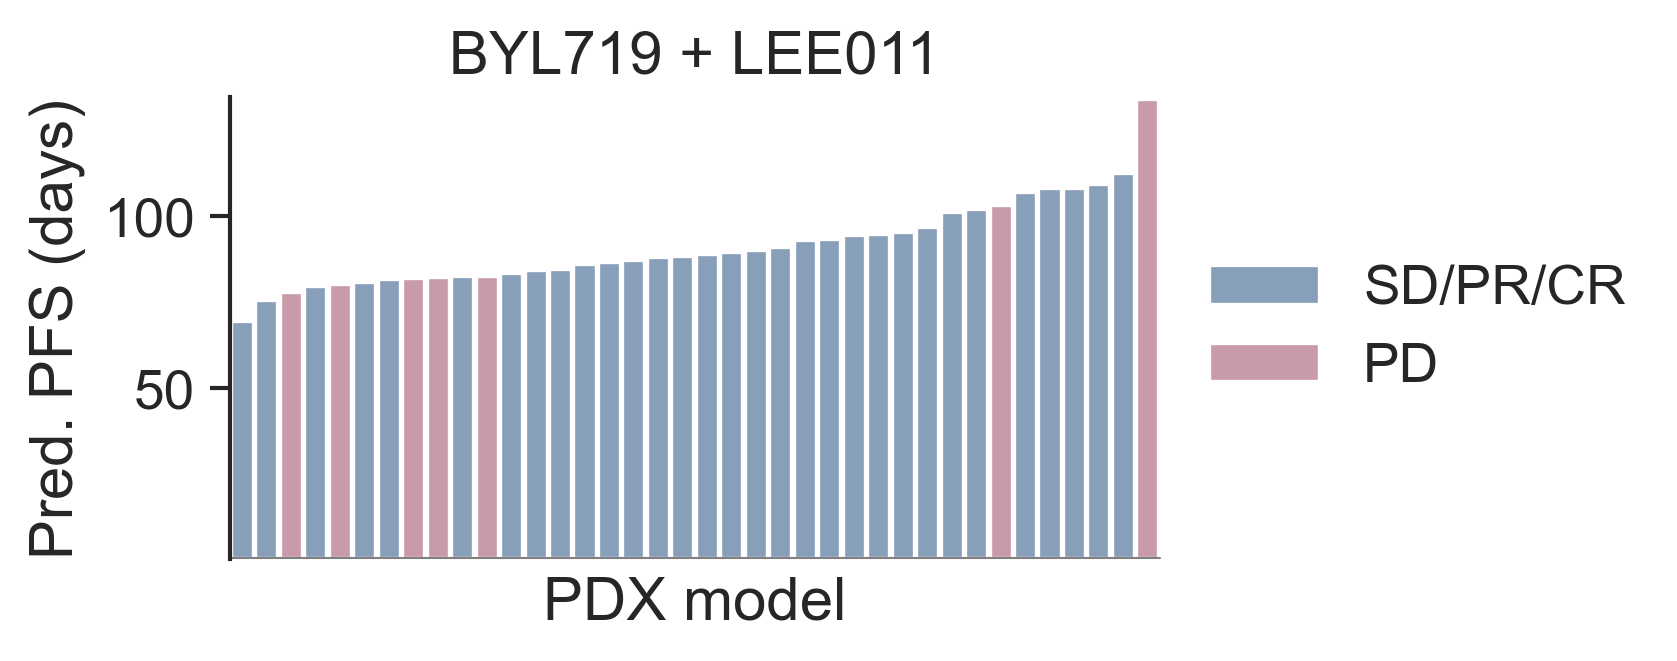

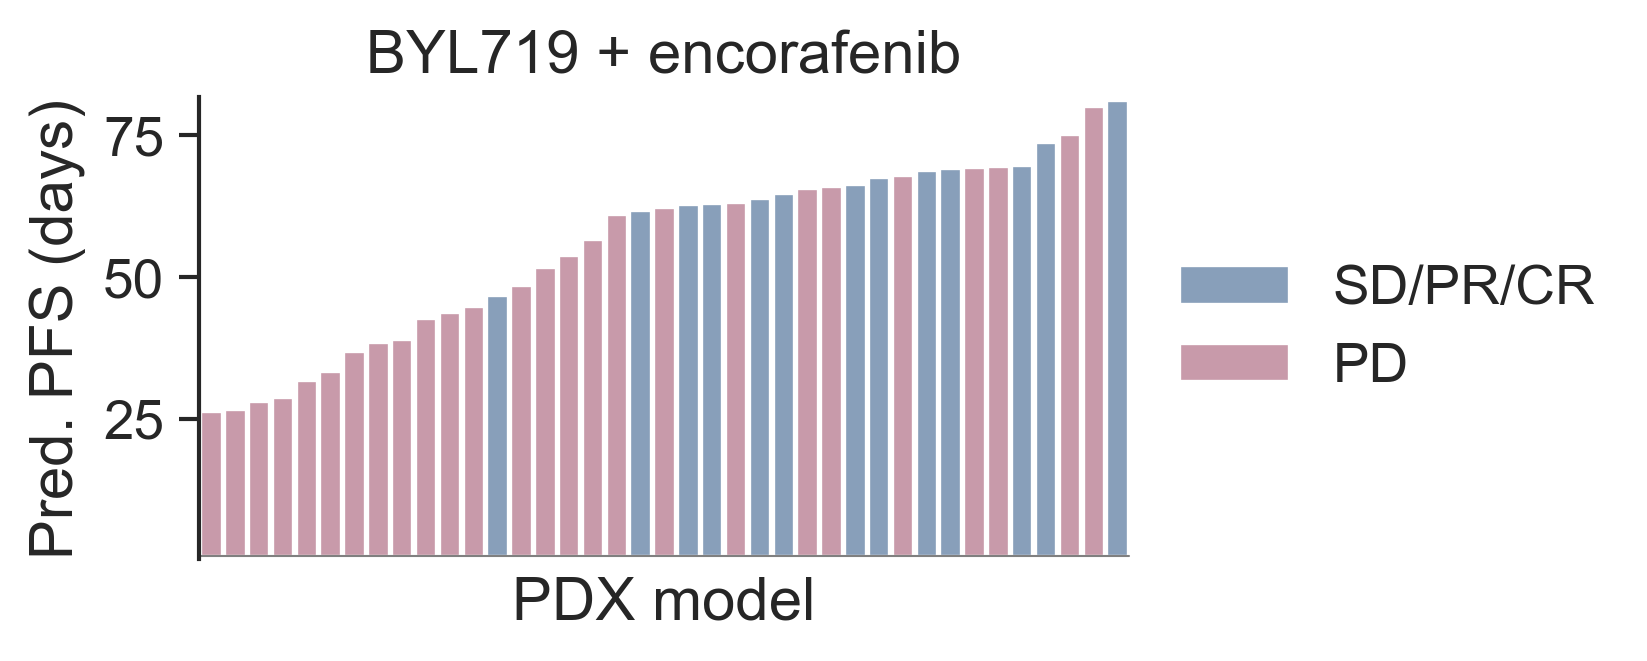

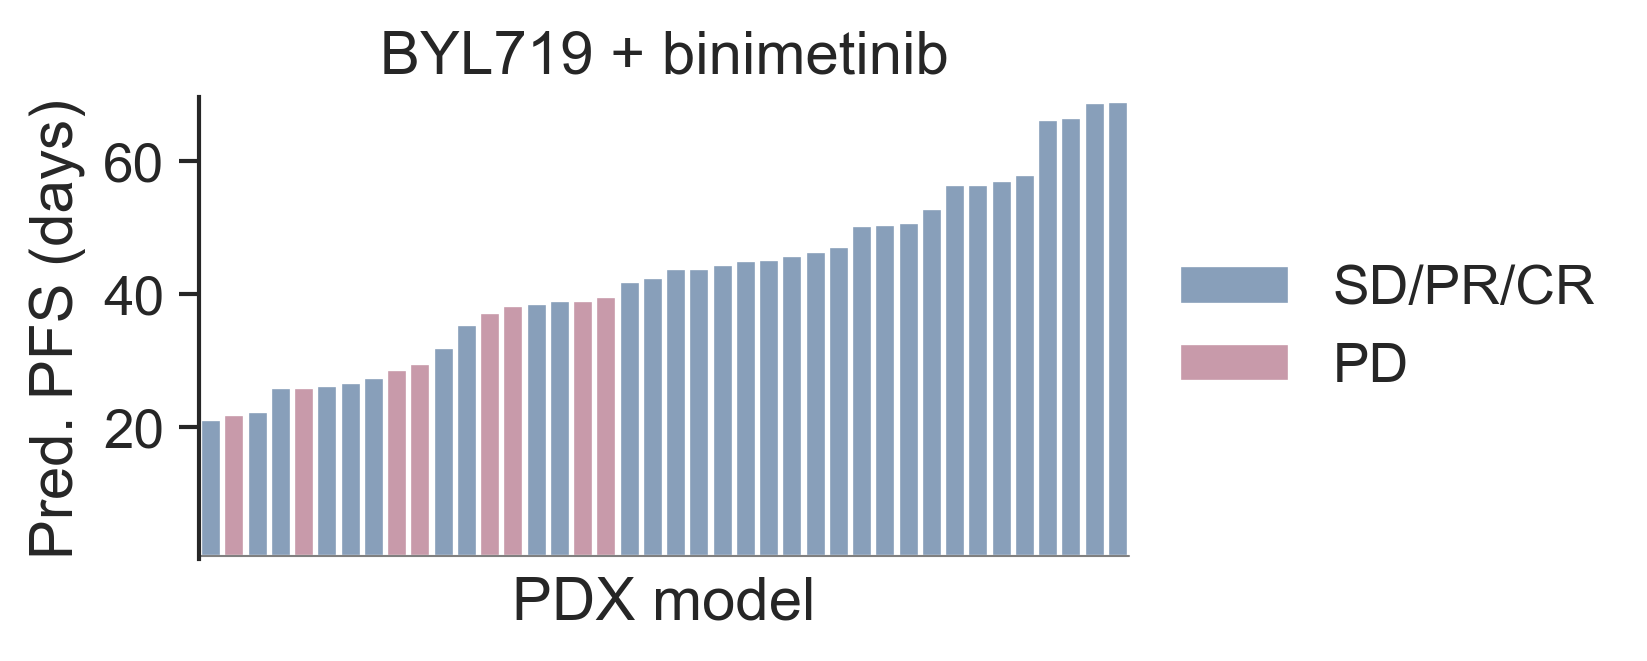

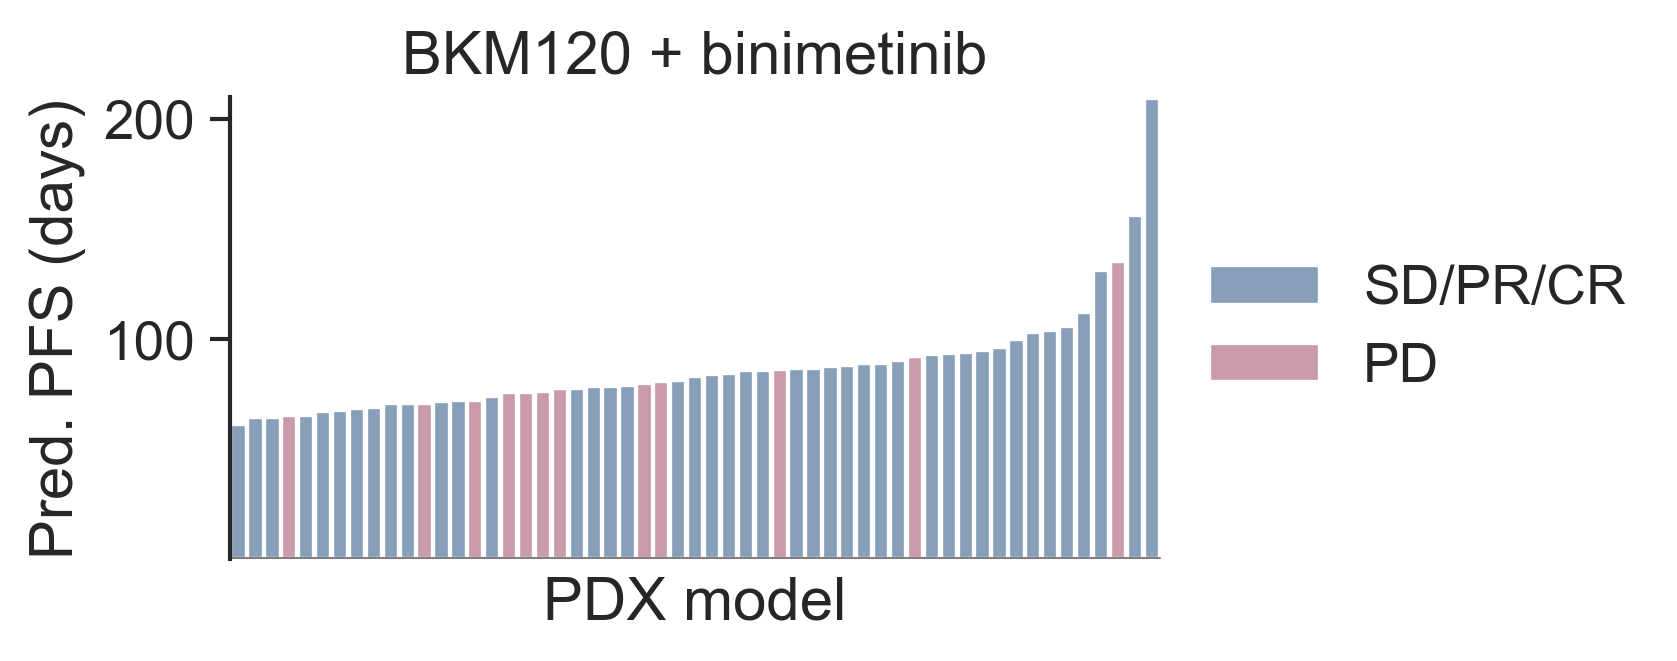

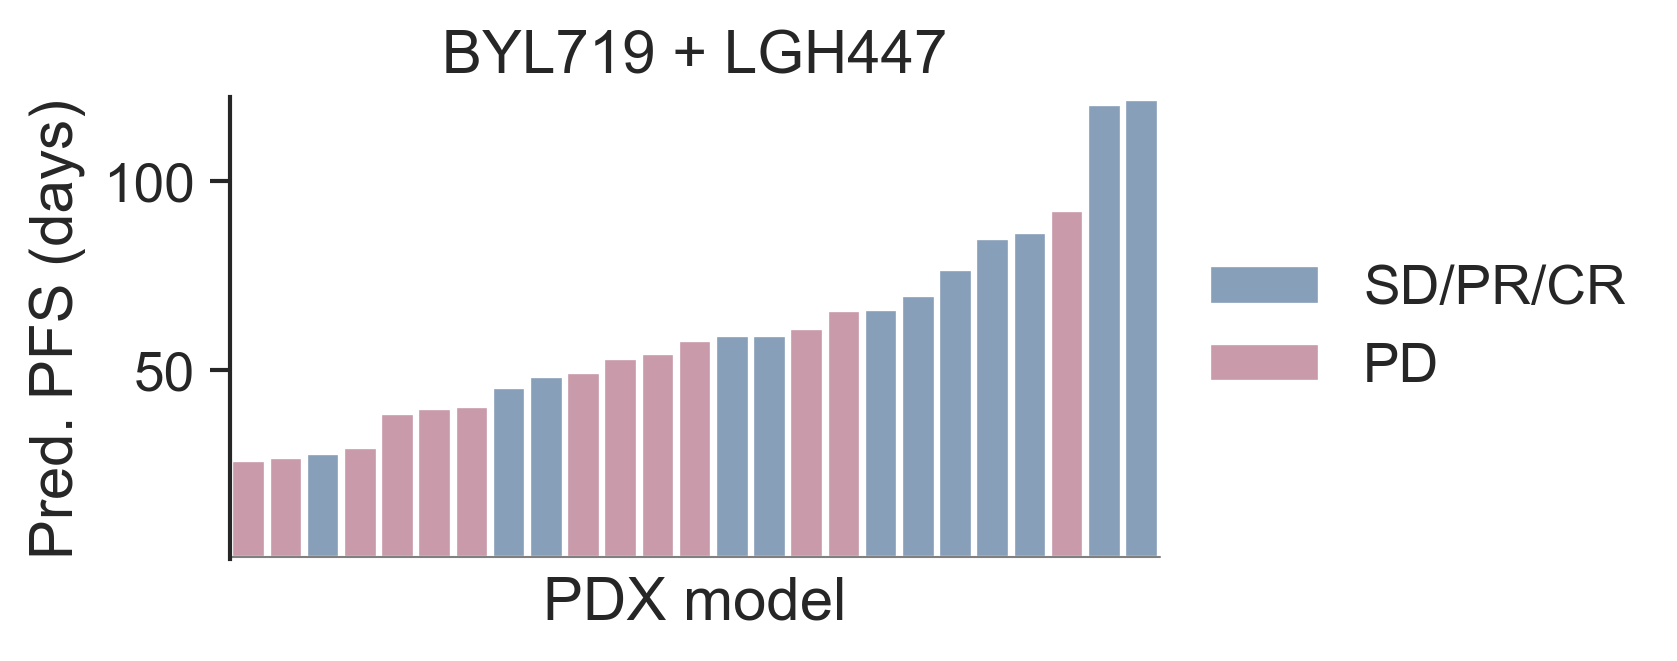

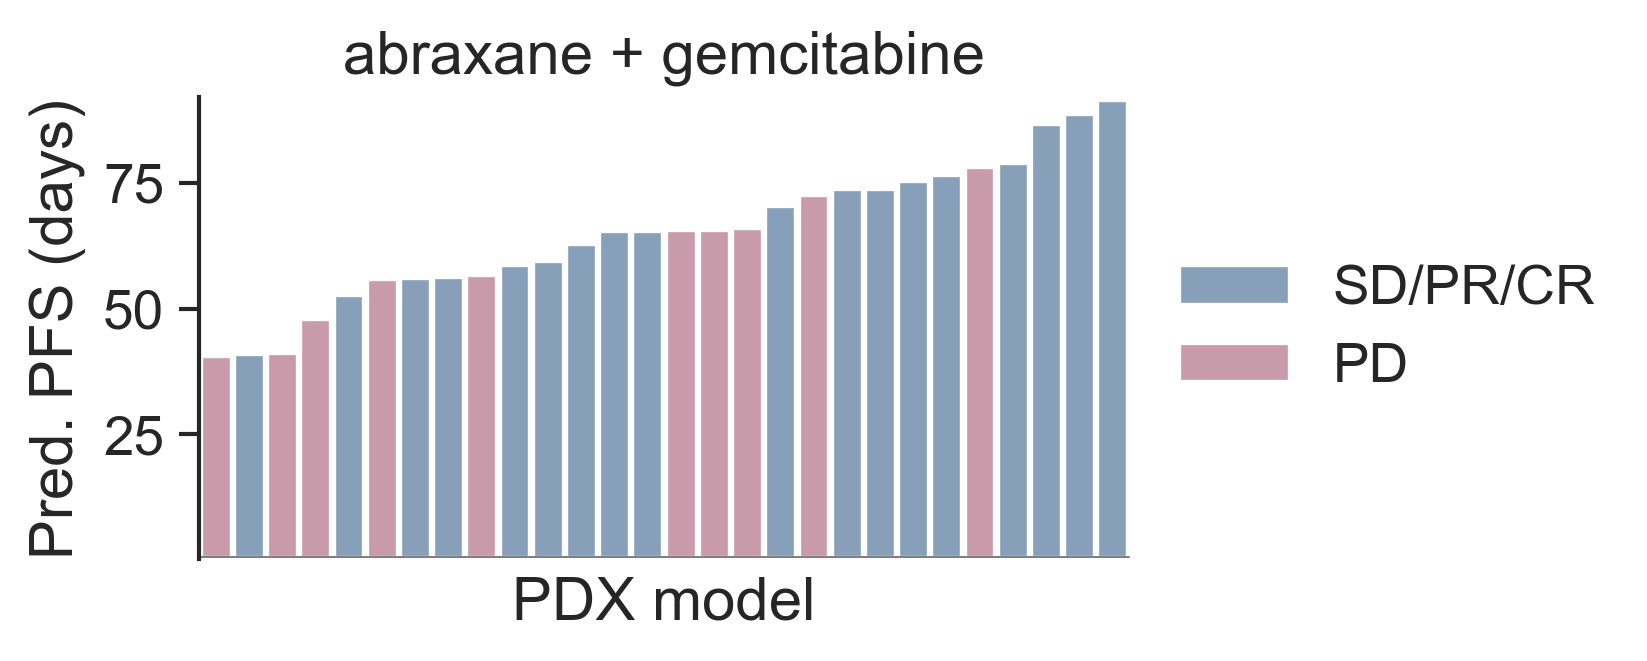

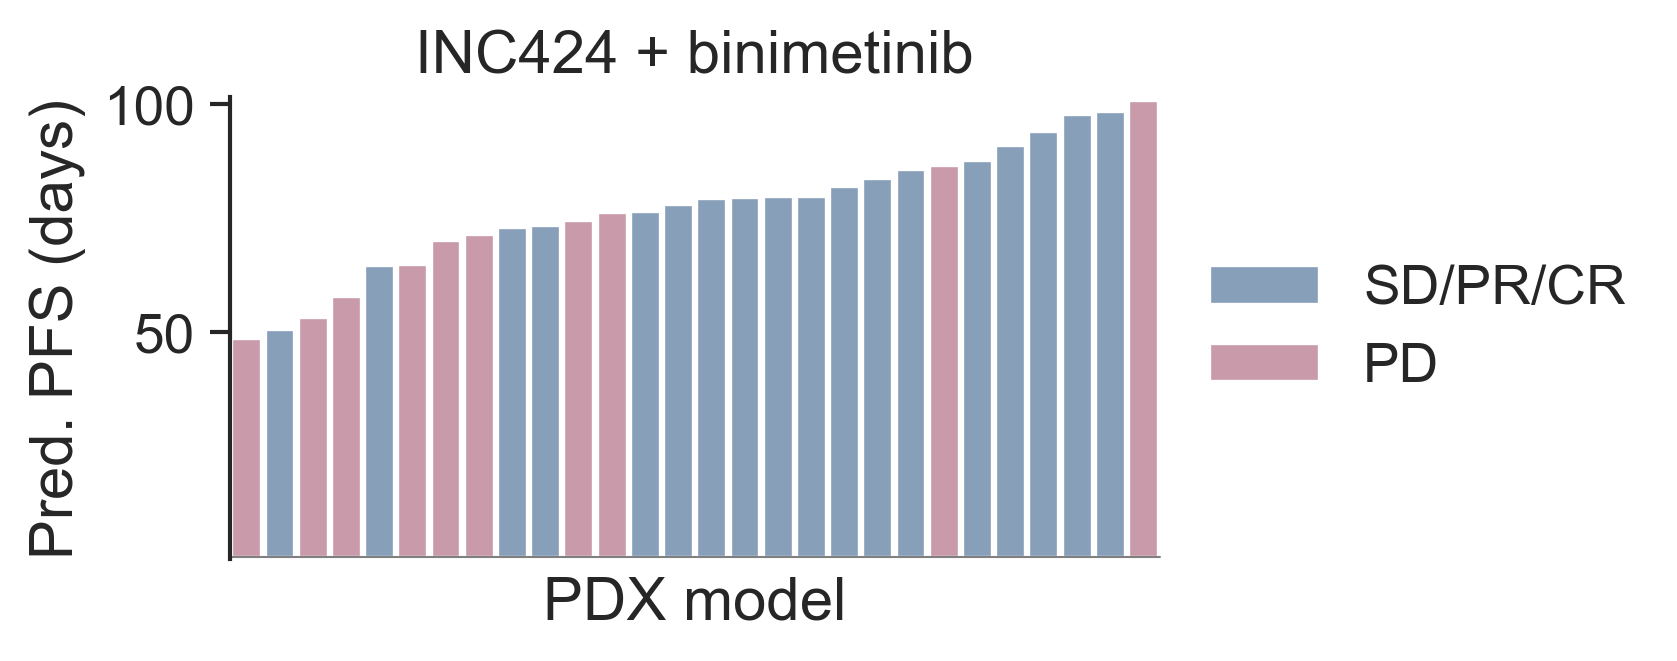

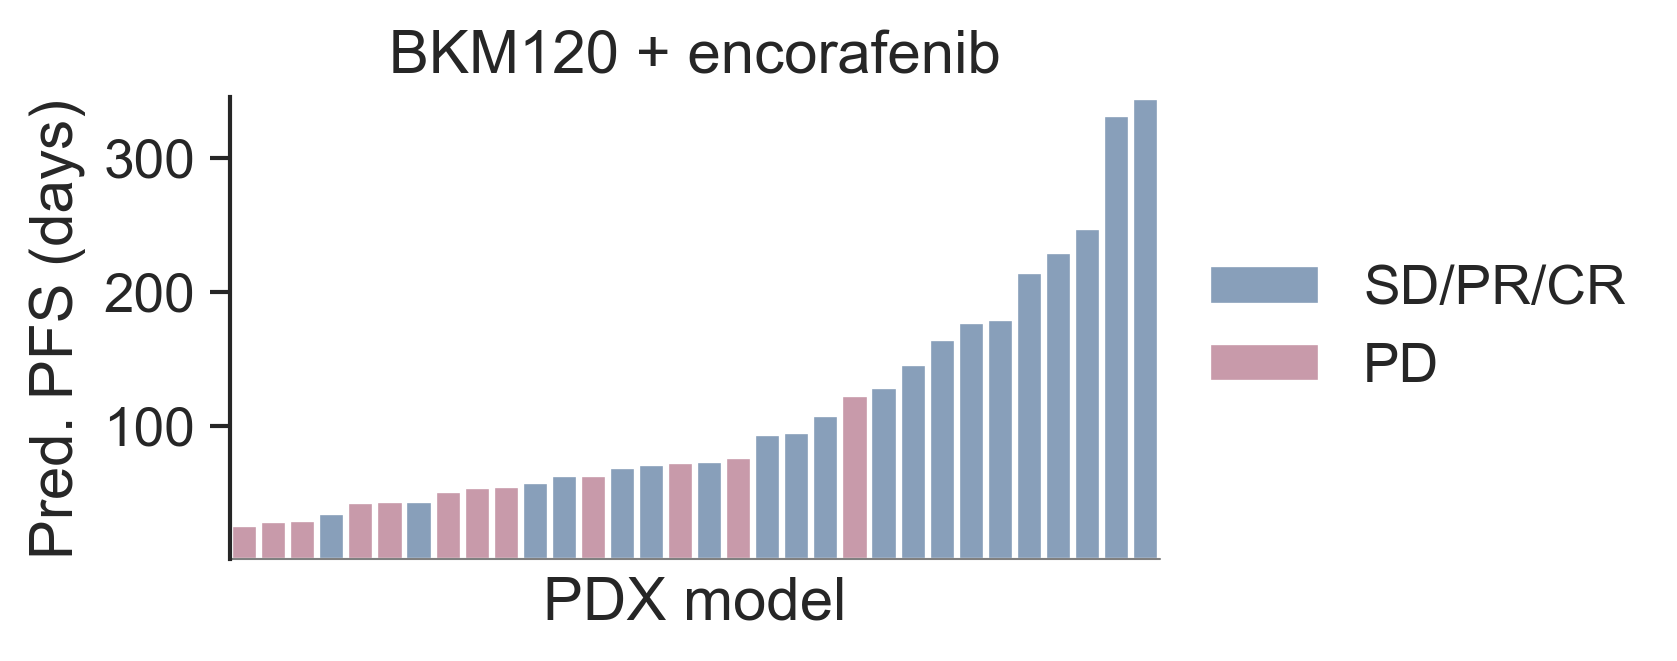

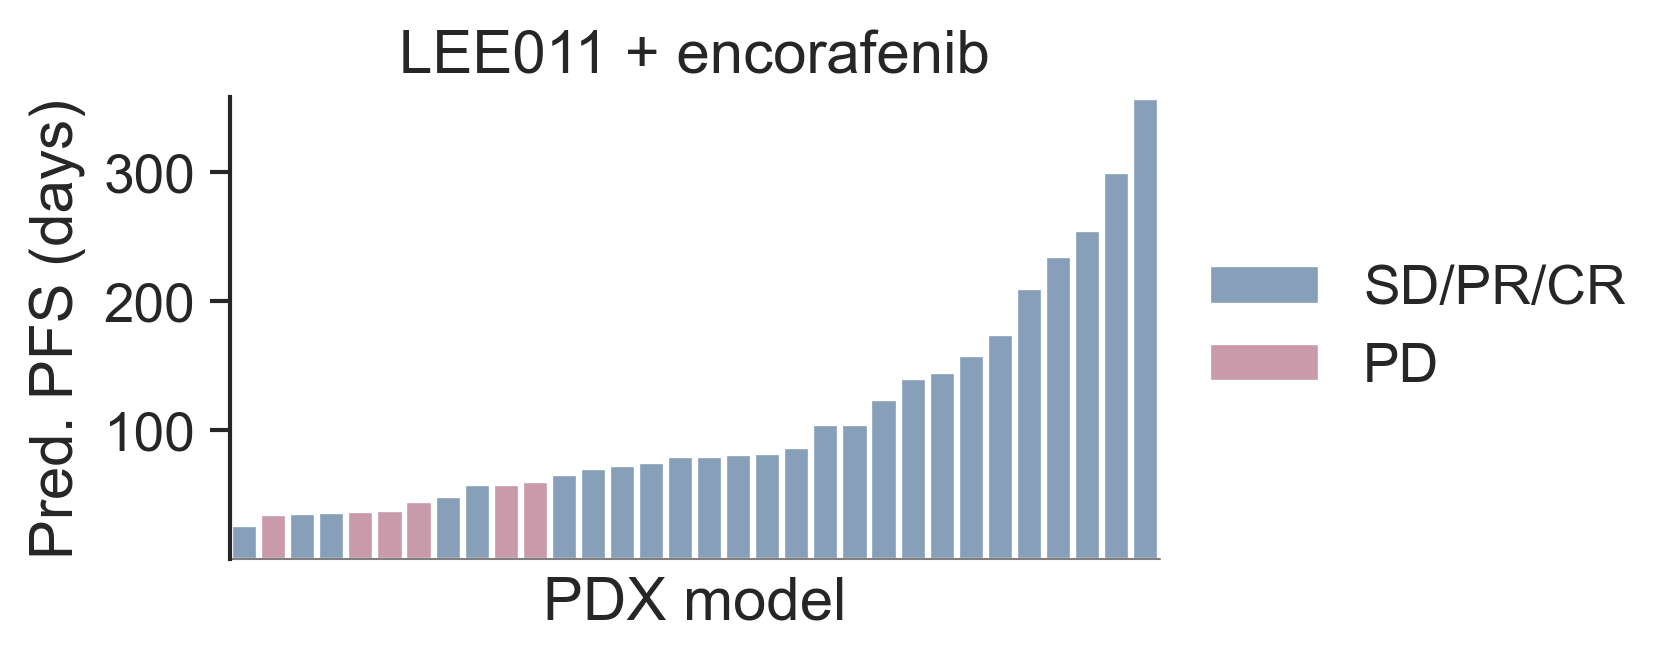

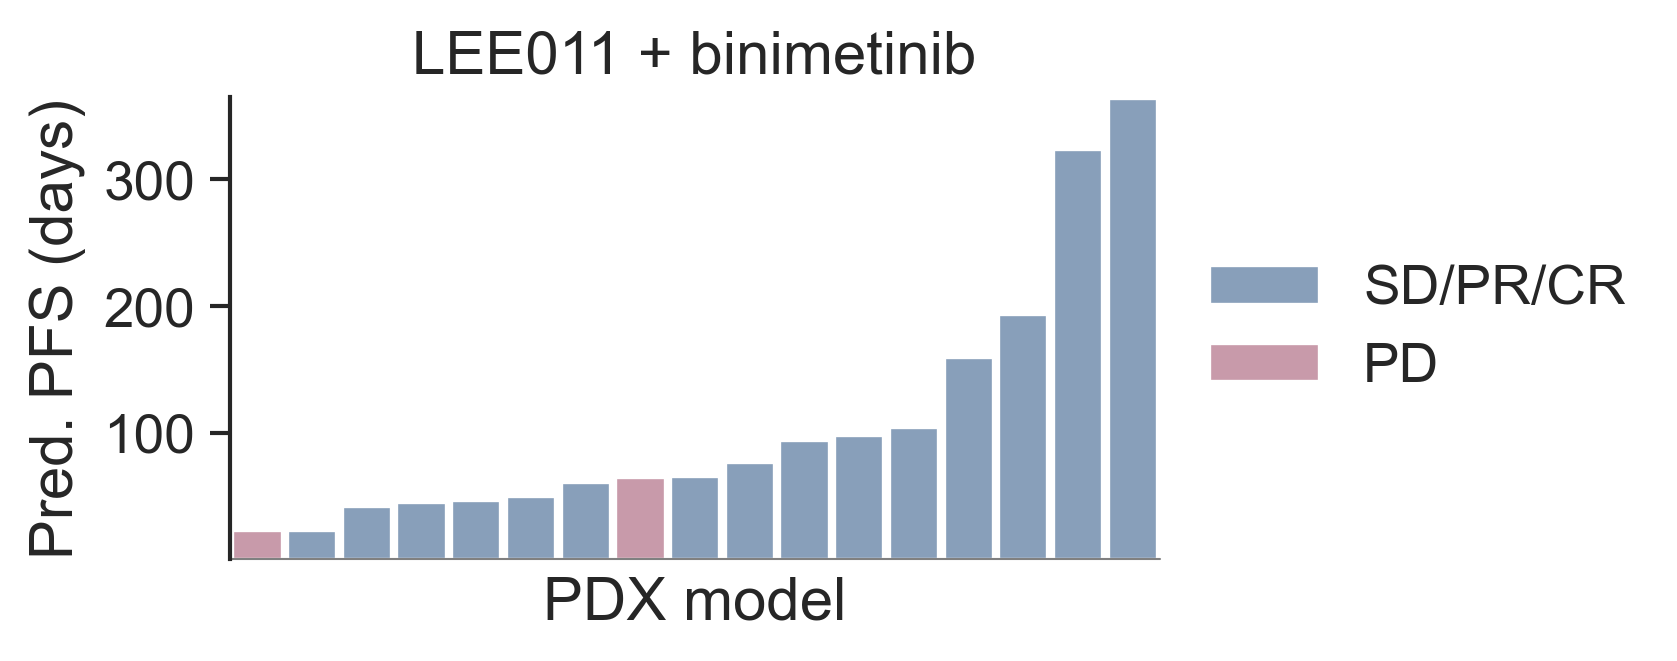

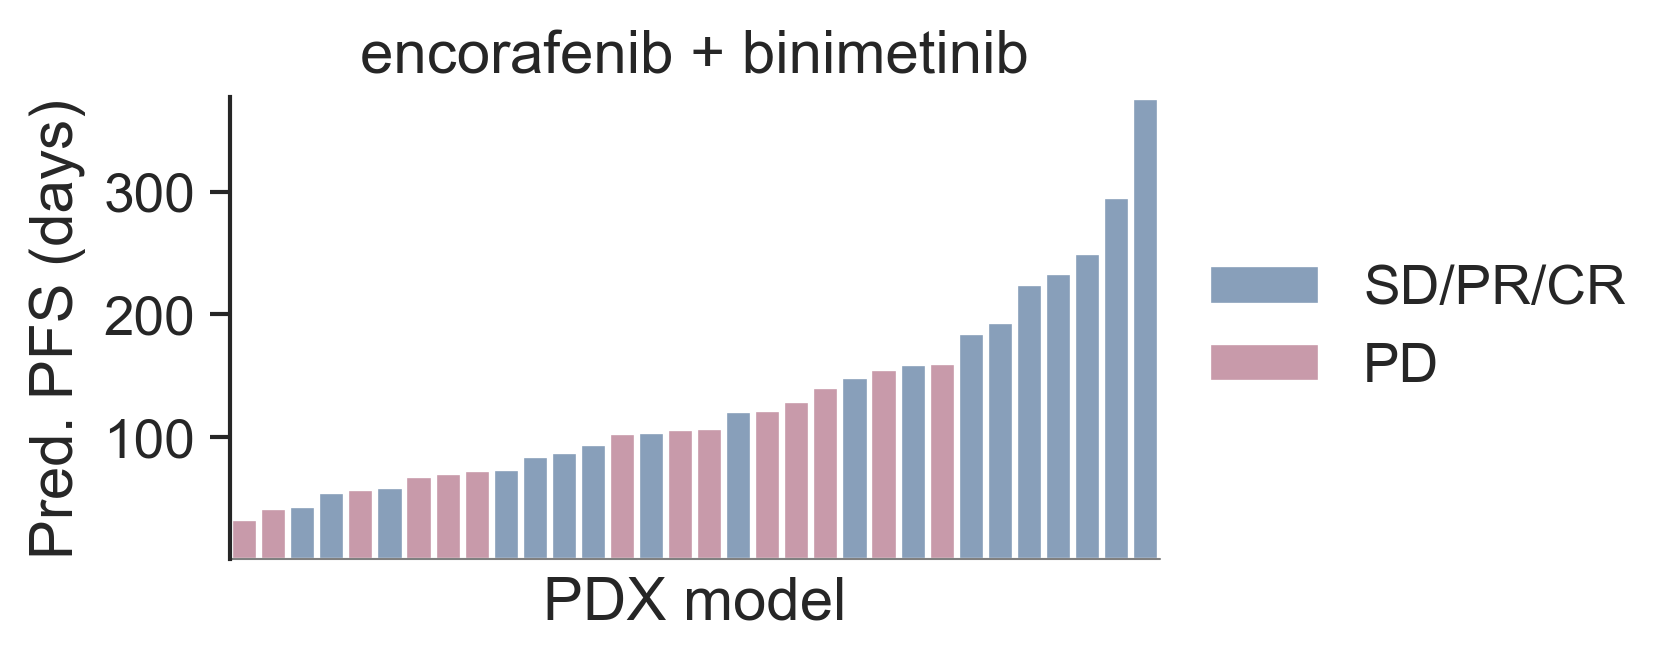

In [20]:
from matplotlib import font_manager as fm
arial_path = "../arial.ttf"
try:
    fm.fontManager.addfont(arial_path)
except OSError:
    pass
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

predicted_outcome = "TimeToDouble"
alternative_outcome = "BestResponseCategory"
for drug_pair, dct in all_drug_pairs_patient_scores_pfs_target.items():
    patients = list(dct.keys())
    pred_scores = list(dct.values())
    alternative_scores = X_metadata[["Model", "Treatment", alternative_outcome]].set_index(["Model", "Treatment"]).loc[(patients, drug_pair), alternative_outcome]
    plot_data = pd.DataFrame.from_dict({
        "Model": patients,
        f"Predicted {predicted_outcome}": pred_scores,
        f"Ground truth {alternative_outcome}": ["PD" if score == "PD" else "SD/PR/CR" for score in alternative_scores],
    })

    fig, ax = plt.subplots(figsize=(4, 2), dpi=300)

    sns.barplot(plot_data, x="Model", y=f"Predicted {predicted_outcome}", hue=f"Ground truth {alternative_outcome}", width=0.9, 
                order=plot_data.sort_values(f"Predicted {predicted_outcome}")["Model"], ax=ax, palette={"PD":"#d092a7", "SD/PR/CR":"#809ec2"},
                hue_order=["SD/PR/CR", "PD"]
               )

    log2 = np.log(2)
    ax.set_ylim(min(min(plot_data[f"Predicted {predicted_outcome}"]), log2) - 0.5, max(max(plot_data[f"Predicted {predicted_outcome}"]), log2) + 0.5)

    # Adjust bar positions
    for bar in ax.patches:
        bar_height = bar.get_height()
        if bar_height >= 0:
            bar.set_y(log2)
            bar.set_height(bar_height - log2)
        else:
            bar.set_y(log2 + bar_height)
            bar.set_height(-bar_height + log2)

    # Add a horizontal line at log(2)
    ax.axhline(y=log2, color='gray', linestyle='-', lw=0.5, clip_on=False)

    plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False, title=None)
    plt.tick_params(
        axis='x',          # changes apply to the x-axis
        which='both',      # both major and minor ticks are affected
        bottom=False,      # ticks along the bottom edge are off
        top=False,         # ticks along the top edge are off
        labelbottom=False) # labels along the bottom edge are off
    plt.title(drug_pair)
    plt.xlabel("PDX model")
    plt.ylabel("Pred. PFS (days)")
    sns.despine(bottom=True)
    
    plt.savefig(f"fig7_pdx_perf_histogram_{drug_pair}.svg", format="svg", dpi=300)
    plt.show()

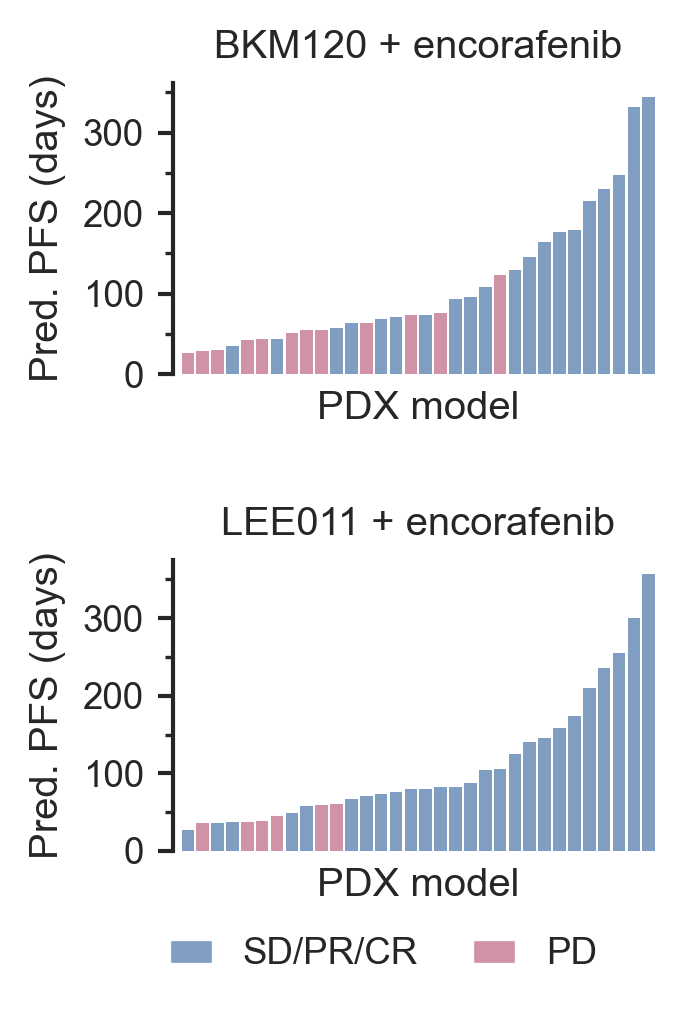

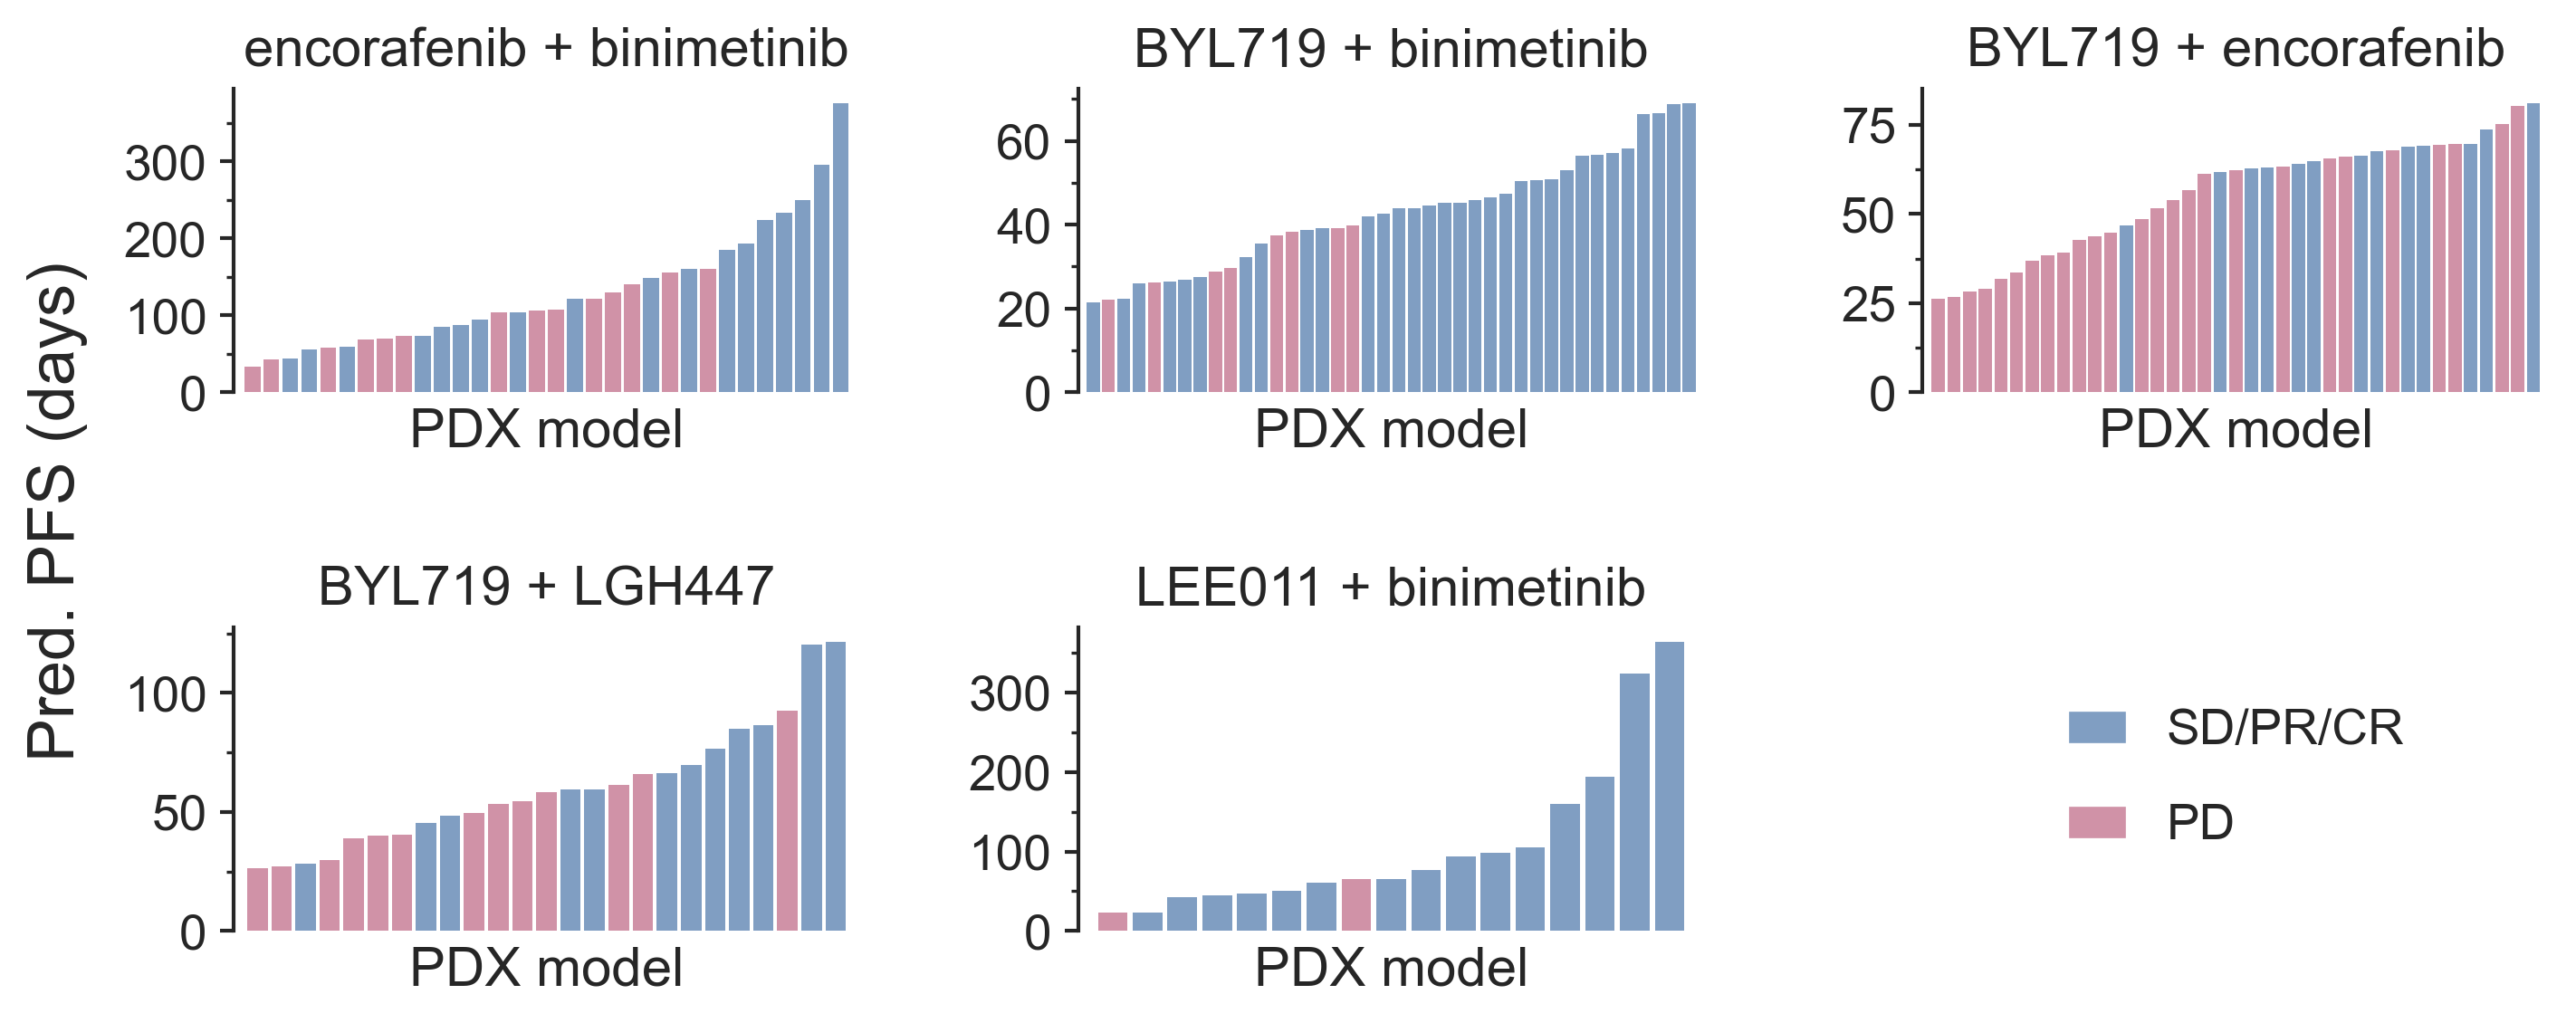

In [32]:
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
from matplotlib.patches import Patch
from matplotlib import font_manager as fm

arial_path = "../arial.ttf"
try:
    fm.fontManager.addfont(arial_path)
except OSError:
    pass
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

predicted_outcome = "TimeToDouble"
alternative_outcome = "BestResponseCategory"

PALETTE = {"PD": "#d092a7", "SD/PR/CR": "#809ec2"}

TOP_PAIRS = ["BKM120 + encorafenib", "LEE011 + encorafenib"]
OTHER_SIG_PAIRS = [
    "encorafenib + binimetinib",
    "BYL719 + binimetinib",
    "BYL719 + encorafenib",
    "BYL719 + LGH447",
    "LEE011 + binimetinib",
]

def nice_step(vmax, target_n_major=4):
    """Smallest 1/2/2.5/5/10-style step that keeps major ticks at or below target_n_major."""
    for exp in range(-2, 6):
        for mant in (1, 2, 2.5, 5):
            step = mant * 10 ** exp
            if vmax / step <= target_n_major:
                return step
    return 10 ** 6

def pfs_bar_panel(ax, drug_pair, show_ylabel=False):
    dct = all_drug_pairs_patient_scores_pfs_target[drug_pair]
    patients = list(dct.keys())
    pred_scores = np.array(list(dct.values()))
    alternative_scores = X_metadata[["Model", "Treatment", alternative_outcome]].set_index(
        ["Model", "Treatment"]).loc[(patients, drug_pair), alternative_outcome]
    categories = np.array(["PD" if s == "PD" else "SD/PR/CR" for s in alternative_scores])

    order = np.argsort(pred_scores)
    heights = pred_scores[order]
    colors = [PALETTE[c] for c in categories[order]]

    ax.bar(np.arange(len(heights)), heights, width=0.85, color=colors, linewidth=0)

    vmax = heights.max()
    ax.set_ylim(0, vmax * 1.05)
    ax.set_xlim(-1, len(heights))

    # Numbered major ticks from 0, plus one unlabelled minor tick between each pair.
    major = nice_step(vmax)
    ax.yaxis.set_major_locator(MultipleLocator(major))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(axis="y", which="major", length=3.5)
    ax.tick_params(axis="y", which="minor", length=2)
    ax.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)

    ax.set_title(drug_pair, pad=6)
    ax.set_xlabel("PDX model")
    ax.set_ylabel("Pred. PFS (days)" if show_ylabel else "")
    sns.despine(ax=ax, bottom=True)

legend_handles = [Patch(facecolor=PALETTE["SD/PR/CR"], label="SD/PR/CR"),
                  Patch(facecolor=PALETTE["PD"], label="PD")]

# ---- Panel A: top-2 tau pairs, stacked ----
sns.set(context="paper", style="ticks", font_scale=1)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

fig, axes = plt.subplots(2, 1, figsize=(2.4, 3.2), dpi=300)
for ax, drug_pair in zip(axes, TOP_PAIRS):
    pfs_bar_panel(ax, drug_pair, show_ylabel=True)
fig.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.55, -0.06),
           ncol=2, frameon=False, columnspacing=1.5, handlelength=1.2)
fig.tight_layout(h_pad=2.0)
plt.savefig("fig7_pdx_perf_histogram_top2_tau.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

# ---- Panel B: the remaining significant pairs, 2 x 3 with the legend in the spare slot ----
sns.set(context="paper", style="ticks", font_scale=1.5)
fig, axes = plt.subplots(2, 3, figsize=(10, 4), dpi=300)
axes_flat = axes.ravel()
for ax, drug_pair in zip(axes_flat, OTHER_SIG_PAIRS):
    pfs_bar_panel(ax, drug_pair, show_ylabel=False)
for ax in axes_flat[len(OTHER_SIG_PAIRS):]:
    ax.axis("off")
axes_flat[len(OTHER_SIG_PAIRS)].legend(handles=legend_handles, loc="center", frameon=False,
                                       handlelength=1.2, labelspacing=1.0)
fig.supylabel("Pred. PFS (days)", x=0.05)
fig.tight_layout(h_pad=2.0, w_pad=2.0, rect=[0.02, 0, 1, 1])
plt.savefig("fig7_pdx_perf_histogram_other_significant.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()